# Projeto Final — Matemática para Ciência de Dados

## Projeto e implementação de uma rede neural com retropropagação manual

| | |
|---|---|
| **Aluno** | _Erasmo de Melo Gusmão_ |
| **Curso** | Especialização em Deep Learning |
| **Disciplina** | Matemática para Ciência de Dados |
| **Professor** | _Adenilton Jose da Silva_ |
| **Modalidade** | Trabalho individual |
| **Data de entrega** | 26/09/2026 |

---

> **Resumo**
>
> _A rede neural proposta e implementada foi uma **2->4->1**.
> Como base de dados utilizei a de círculos concêntricos do sklearn (`sklearn.datasets.make_circles`) e, além dessa modificação em relação ao `exemplo4.py`, também propus usar uma camada oculta com largura igual a 4 neurônios e a **tanh** como função de ativação._

---

**Enunciado da atividade (Aula 04 — 21/08/2026):**

> Neste projeto você deve projetar e implementar uma rede neural seguindo o arquivo `exemplo4.py`
> disponível no material da aula do dia 21/08/2026. Por exemplo, você pode alterar o número de
> neurônios, número de camadas, função de ativação e base de dados. Cada grupo pode escolher as
> modificações que irá realizar, inclusive realizar modificações diferentes das sugeridas.
> Data de entrega: 26/09/2026.

---
## 1. Modificações em relação ao `exemplo4.py`


| Aspecto | Baseline (`exemplo4.py`) | Proposto neste trabalho | Justificativa |
|---|---|---|---|
| Base de dados | `make_moons(100, noise=0.1)` | `make_circles(400, noise=0.1, factor=0.5)` | Círculos concêntricos: a classe interna precisa ser **cercada** por todos os lados, o que exige mais retas (neurônios) do que as duas luas. |
| Nº de camadas ocultas | 1 | 1 (mantido) | Isola o efeito da **largura**; a profundidade é varrida no PyTorch na seção de experimento. Mantém o backward manual legível e o grafo desenhável. |
| Nº de neurônios por camada | 2 → 2 → 1 | **2 → 4 → 1** | Quatro retas bastam para cercar o círculo interno com um quadrilátero; duas não fecham região alguma. 17 parâmetros contra 9. |
| Função de ativação (ocultas) | sigmoide | **tanh** | Saída centrada em zero e derivada máxima 1 (contra 0,25 da sigmoide): gradiente maior e menos viés nas atualizações da camada seguinte. |
| Função de ativação (saída) | sigmoide | sigmoide (mantida) | Saída em $(0,1)$, interpretável como probabilidade da classe 1 e compatível com o limiar 0,5. |
| Função de perda | erro quadrático (½e²) | ½e² (mantida) | Mantém a comparabilidade com o baseline. |
| Inicialização dos pesos | `np.random.rand` (U[0,1]) | Xavier/Glorot, $\mathcal{N}(0,\,1/n_{\text{ent}})$, semente fixa | U[0,1] gera pesos todos positivos com média 0,5, o que empurra a tanh para a saturação. Xavier mantém a variância das ativações entre camadas. |
| Agregação do gradiente | soma sobre as amostras | **média** (÷N) | Com a soma, o passo efetivo cresce com N; com a média a taxa de aprendizado tem o mesmo significado para qualquer tamanho de conjunto. |
| Divisão treino/teste | ausente | 70/30 estratificada + `StandardScaler` ajustado no treino | O baseline mede acurácia no próprio conjunto de treino; sem teste não há como falar em generalização. |
| Comparação com framework | Keras | PyTorch | O `autograd` permite conferir os gradientes manuais contra a diferenciação automática. |


---
# 2. Preparação do ambiente

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import sklearn, matplotlib
print("Python     :", sys.version.split()[0])
print("numpy      :", np.__version__)
print("sklearn    :", sklearn.__version__)
print("matplotlib :", matplotlib.__version__)

plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["figure.dpi"] = 110

Python     : 3.13.5
numpy      : 2.5.3
sklearn    : 1.9.1
matplotlib : 3.11.2


## 2.1 Parâmetros globais do experimento

Centralizar as constantes aqui evita números mágicos espalhados pelo notebook e torna o trabalho
reprodutível.

In [2]:
# ---- reprodutibilidade -------------------------------------------------
SEED = 13
np.random.seed(SEED)

# ---- base de dados (decisão: círculos concêntricos) --------------------
DATASET    = "circles"   # sklearn.datasets.make_circles
N_AMOSTRAS = 400
RUIDO      = 0.10
FATOR      = 0.50        # razão entre o raio interno e o externo
TEST_SIZE  = 0.30

# ---- arquitetura proposta (decisão: 2 -> 4 -> 1) ------------------------
N_OCULTOS  = 4           # largura da única camada oculta (baseline: 2)
ATIV_OCULTA = "tanh"     # ativação da camada oculta   (baseline: sigmoide)
ATIV_SAIDA  = "sigmoid"  # ativação da saída           (mantida)

# ---- treinamento -------------------------------------------------------
TAXA   = 1.0      # eta — taxa de aprendizado (ver seção 1, "Agregação do gradiente": com gradiente
                  # calculado como média, valores maiores que o do exemplo4.py podem ser necessários). Varredura das taxas na seção 8.4
EPOCAS = 5000     # nº de iterações do gradiente descendente

print(f"dataset={DATASET}  N={N_AMOSTRAS}  ruido={RUIDO}  fator={FATOR}  "
      f"arquitetura=2->{N_OCULTOS}->1 ({ATIV_OCULTA}/{ATIV_SAIDA})  eta={TAXA}  epocas={EPOCAS}")


dataset=circles  N=400  ruido=0.1  fator=0.5  arquitetura=2->4->1 (tanh/sigmoid)  eta=1.0  epocas=5000


---
# 3. Base de dados

**Modificação em relação ao baseline:** o `exemplo4.py` usa `make_moons` (duas luas). Aqui é usado
`make_circles`: dois anéis concêntricos, o interno com metade do raio do externo (`factor=0.5`),
com ruído gaussiano de desvio 0,1 nas coordenadas.

A escolha é deliberada. Nas duas luas, uma fronteira curva única já separa as classes, e a rede
2→2→1 do baseline chega a acertar a maioria dos pontos. Nos círculos, a classe interna precisa
ser **cercada** por todos os lados: com apenas duas retas (dois neurônios ocultos) não é possível
fechar uma região do plano, e o baseline tende a ficar próximo da acurácia de chance. Isso
justifica diretamente o aumento da largura para quatro neurônios, o mínimo para delimitar um
quadrilátero em torno do anel interno. O problema continua bidimensional, então a fronteira de
decisão aprendida pode ser desenhada.

## 3.1 Geração dos dados


In [3]:
X, Y = datasets.make_circles(
    n_samples=N_AMOSTRAS, noise=RUIDO, factor=FATOR, random_state=SEED)

print("X:", X.shape, " Y:", Y.shape, " classes:", np.unique(Y, return_counts=True))

X: (400, 2)  Y: (400,)  classes: (array([0, 1]), array([200, 200]))


## 3.2 Visualização do conjunto

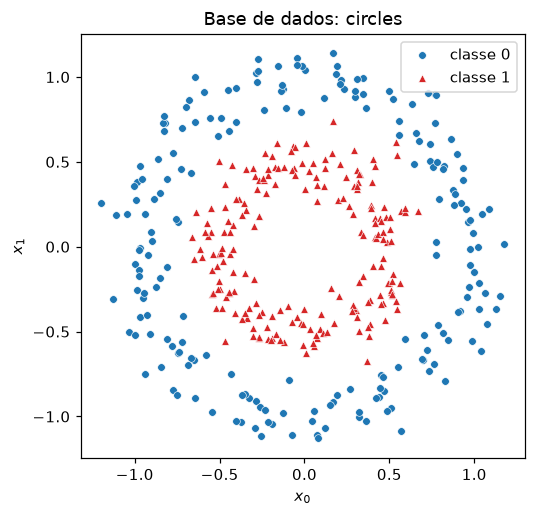

In [4]:
# Plota o conjunto de dados no plano (x0, x1), colorindo por classe.

# Criar figura e eixo
fig, ax = plt.subplots()

# Configuração visual de cada classe
for classe, cor, marcador in [(0, "tab:blue", "o"), (1, "tab:red", "^")]:

    # Máscara booleana:
    # seleciona apenas os elementos pertencentes à classe atual
    m = (Y == classe)

    # Plotar os pontos da classe
    ax.scatter(
        X[m, 0],            # x0
        X[m, 1],            # x1
        c=cor, 
        marker=marcador, 
        s=25,
        edgecolor="white", 
        linewidth=0.4, 
        label=f"classe {classe}"
        )

# Configuração dos eixos
ax.set_xlabel("$x_0$"); 
ax.set_ylabel("$x_1$")
# Título
ax.set_title(f"Base de dados: {DATASET}")
# Legenda
ax.legend();   
# Mesma escala nos dois eixos
ax.set_aspect("equal");

plt.show()

## 3.3 Divisão treino/teste e normalização

_A necessidade de normalizar está diretamente relacionada à escala das entradas, que multiplicam diretamente o gradiente: atributos em escalas diferentes produzem gradientes desbalanceados, e entradas grandes levam a sigmoide/tanh à região de saturação, onde a derivada é praticamente nula._

⚠️ **Importante:** o `StandardScaler` é ajustado (`fit`) **somente no conjunto de treino** e apenas aplicado (`transform`) no de teste — caso contrário haveria vazamento de informação.

In [5]:
# Dividir em treino/teste e normalizar, nesta ordem.

# 1. Separar os dados em treino e teste
X_tr, X_te, Y_tr, Y_te = train_test_split(X, Y, test_size=TEST_SIZE, random_state=SEED, stratify=Y)

# 2. Criar o normalizador
scaler = StandardScaler()

# 3. Aprender média e desvio-padrão SOMENTE do treino
scaler.fit(X_tr)

# 4. Padronizando os dados de treino
X_tr = scaler.transform(X_tr)

# 5. Padronizando os dados de teste usando os MESMOS parâmetros do treino
X_te = scaler.transform(X_te)

print("treino:", X_tr.shape, " teste:", X_te.shape)

treino: (280, 2)  teste: (120, 2)


## 3.4 Utilitário: fronteira de decisão

Função usada para desenhar a fronteira de decisão ao longo do projeto. Ela fica definida aqui, antes de qualquer rede, para
que cada seção de treinamento possa desenhá-la.

A `funcao_predicao` recebe uma matriz `(N, 2)` e devolve um vetor de rótulos 0/1.

In [6]:
def plota_fronteira(X, Y, funcao_predicao, titulo="", passo=0.02, ax=None, X_teste=None, Y_teste=None, fontsize="small"):
    """
    Desenha a fronteira de decisão aprendida sobre o espalhamento dos dados.

    Parâmetros
    ----------
    X, Y :
        Dados de treino padronizados e rótulos.

    funcao_predicao :
        Função que recebe matriz (N, 2) e retorna vetor de rótulos 0/1.

    X_teste, Y_teste :
        Dados de teste opcionais.

    ax :
        Eixo do matplotlib. Se None, cria uma nova figura.
    """

    # Se nenhum eixo foi fornecido, cria uma nova figura
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    # 1. Intervalo dos dados com folga de 0.5
    x0_min = X[:, 0].min() - 0.5
    x0_max = X[:, 0].max() + 0.5

    x1_min = X[:, 1].min() - 0.5
    x1_max = X[:, 1].max() + 0.5

    # 2. Criar a malha
    xx, yy = np.meshgrid(
        np.arange(x0_min, x0_max, passo),
        np.arange(x1_min, x1_max, passo)
    )

    # 3. Transformar a malha em pares (x0, x1)
    pontos_malha = np.c_[xx.ravel(), yy.ravel()]

    # Fazer a predição para cada ponto da malha
    Z = funcao_predicao(pontos_malha)

    # Voltar para o formato da malha
    Z = Z.reshape(xx.shape)

    # 4. Desenhar as regiões da fronteira
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")

    # 5. Plotar os dados de treino
    for classe, cor, marcador in [(0, "tab:blue", "o"), (1, "tab:red", "^")]:

        m = (Y == classe)

        ax.scatter(
            X[m, 0],
            X[m, 1],
            c=cor,
            marker=marcador,
            s=25,
            edgecolor="black",
            linewidth=0.4,
            label=f"treino - classe {classe}"
        )

    # Plotar dados de teste, se fornecidos
    if X_teste is not None and Y_teste is not None:

        for classe, cor in [(0, "tab:blue"), (1, "tab:red")]:

            m = (Y_teste == classe)

            ax.scatter(
                X_teste[m, 0],
                X_teste[m, 1],
                c=cor,
                marker="x",
                s=40,
                linewidth=1.2,
                label=f"teste - classe {classe}"
            )

    # 6. Rótulos e título
    ax.set_xlabel("$x_0$ (padronizado)")
    ax.set_ylabel("$x_1$ (padronizado)")
    ax.set_title(titulo)

    ax.legend(fontsize=fontsize)

    # 7. Retorna o eixo
    return ax

---
# 4. Funções de ativação e suas derivadas

Implementação das funções derivadas analiticamente.

In [7]:
def sigmoid(v):
    """Sigmoide logística: 1 / (1 + exp(-v))."""
    return 1 / (1 + np.exp(-v))


def d_sigmoid(v):
    """Derivada da sigmoide, em função de v."""
    # É phi'(v) = phi(v) * (1 - phi(v)).
    # Nota: no exemplo4.py o professor escreve `grad_v2 = grad_y2 * y2 * (1 - y2)`,
    # ou seja, reaproveita a saída y já calculada no forward em vez de recalcular a sigmoide.
    # Eu escolhi implementar a forma phi'(v) = phi(v) * (1 - phi(v))
    phi = sigmoid(v)
    return phi * (1 - phi)


def tanh(v):
    """Tangente hiperbólica."""
    return np.tanh(v)


def d_tanh(v):
    """Derivada da tanh: 1 - tanh(v)**2."""
    return 1 - tanh(v)**2


def relu(v):
    """ReLU: max(0, v)."""
    return np.maximum(0, v)


def d_relu(v):
    """Derivada da ReLU (convenção: 0 em v = 0)."""
    return (v > 0).astype(float)


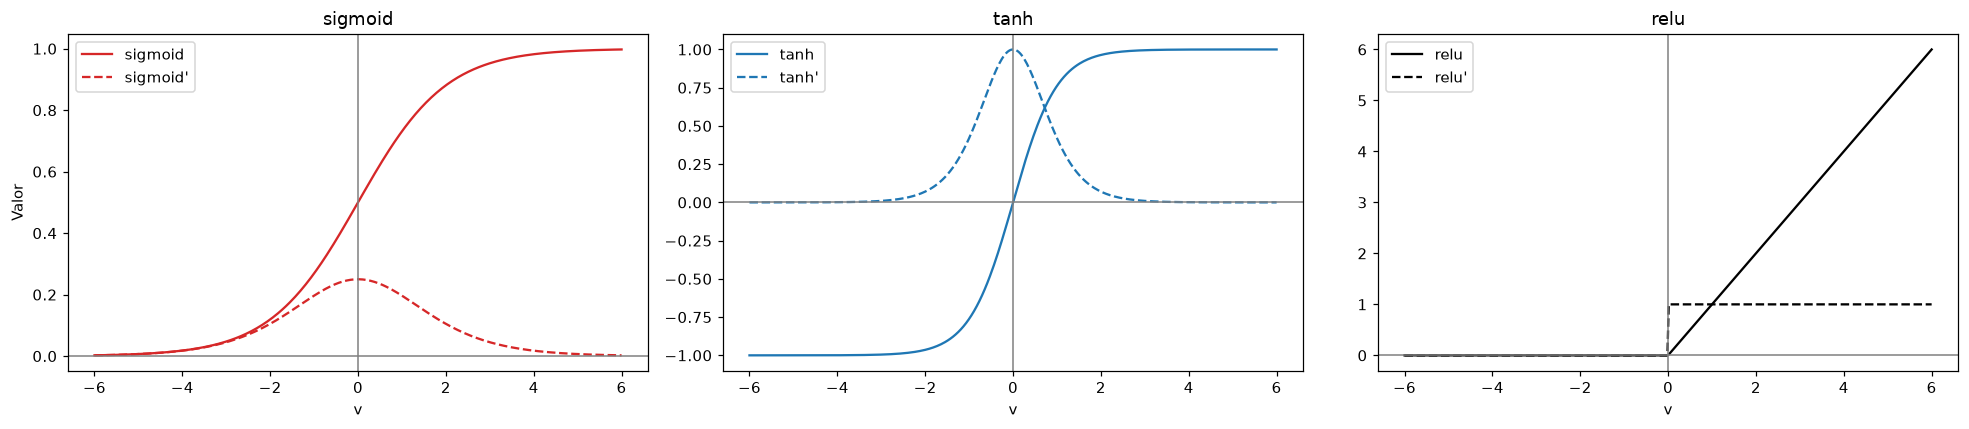

In [8]:
# Gráfico comparando as três ativações e suas derivadas.
# Apoio visual.

v = np.linspace(-6, 6, 400)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

ativacoes = [
    (sigmoid, d_sigmoid),
    (tanh, d_tanh),
    (relu, d_relu)
]

cores = ["tab:red", "tab:blue", "black"]

for i, ((ativacao, derivada), cor) in enumerate(zip(ativacoes, cores)):

    # Função de ativação
    axes[i].plot(
        v,
        ativacao(v),
        c=cor,
        label=ativacao.__name__
    )

    # Derivada
    axes[i].plot(
        v,
        derivada(v),
        c=cor,
        linestyle="--",
        label=f"{ativacao.__name__}'"
    )

    # Eixos de referência
    axes[i].axhline(
        y=0,
        color="gray",
        linewidth=1
    )

    axes[i].axvline(
        x=0,
        color="gray",
        linewidth=1
    )

    axes[i].set_title(ativacao.__name__)
    axes[i].set_xlabel("v")
    axes[i].legend()

axes[0].set_ylabel("Valor")

plt.tight_layout()
plt.show()

---
# 5. Baseline — reprodução do `exemplo4.py`

Reprodução fiel da rede do professor (**2 → 2 → 1**, sigmoide em todas as camadas), agora sobre a
nova base de dados. Serve como **referência de comparação**: sem ela não é possível afirmar que as
modificações trouxeram ganho.

O estilo de escrita é o do material da aula: cada operação elementar recebe um nome
(`s00`, `s01`, `v0`, `y0`, ...) e o backward espelha esses nomes com o prefixo `grad_`.


## 5.1 Grafo computacional do baseline — forward e backward

Grafo computacional da rede 2→2→1: rótulos pretos são as variáveis de `forward_baseline`, rótulos vermelhos os gradientes de `backward_baseline`.


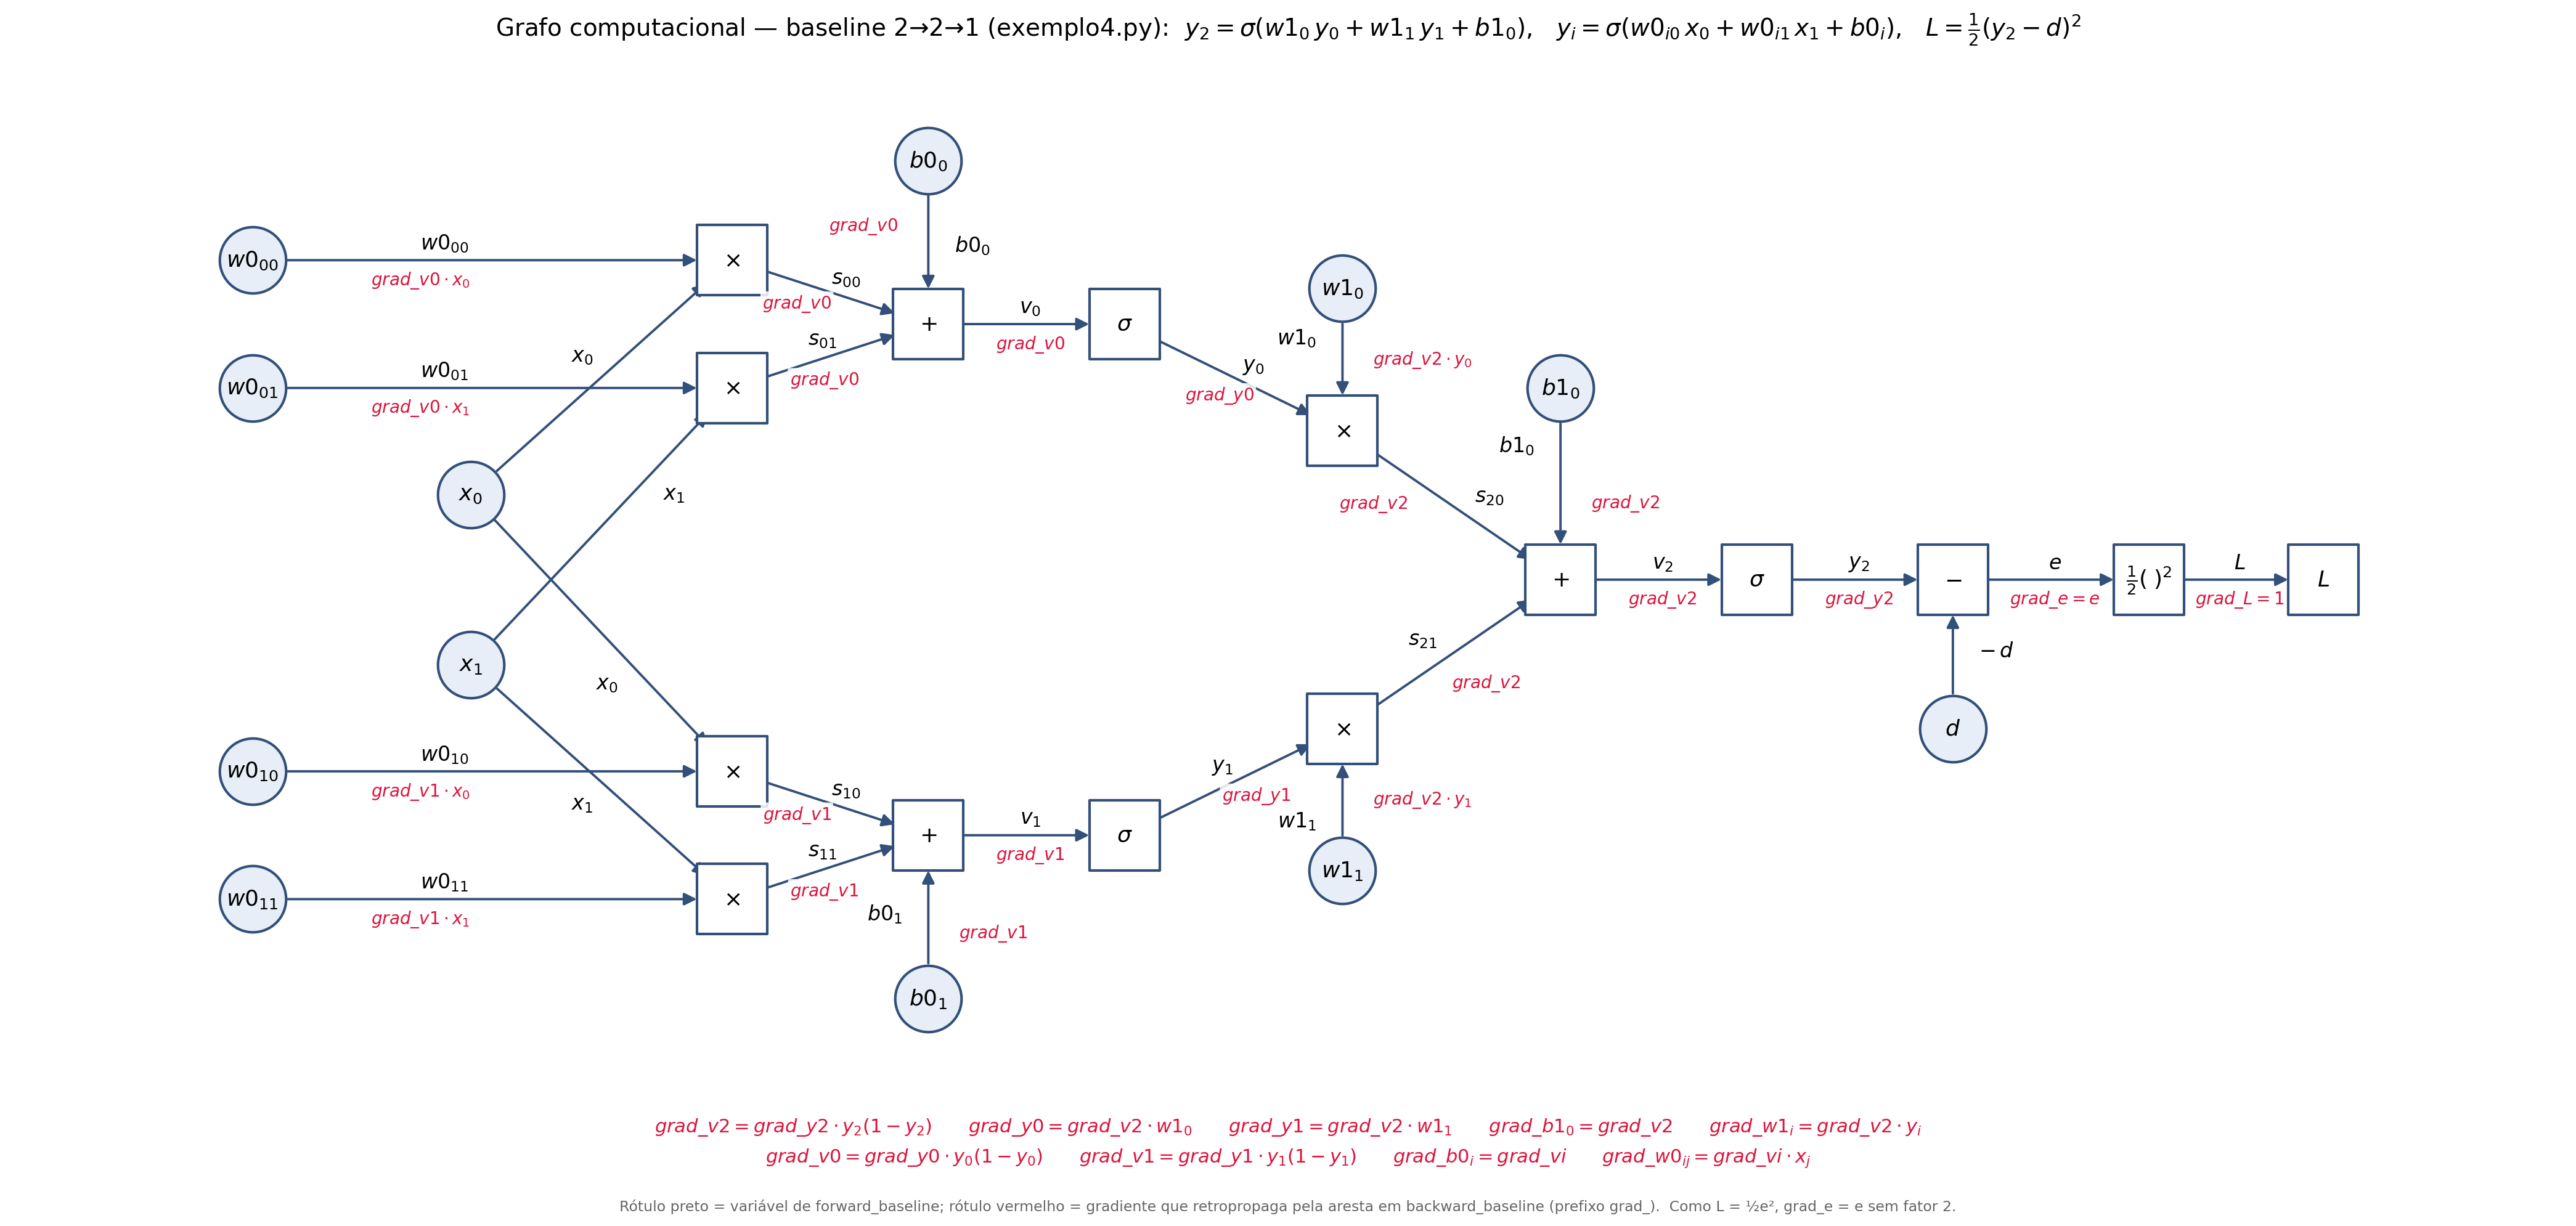

In [9]:
from IPython.display import Image
Image("figuras/grafos/grafo_baseline_2-2-1.png")

In [10]:
def inicializa_baseline(seed=None) -> tuple:
    """Inicializa os pesos da rede 2-2-1 do exemplo4.py.

    Retorna
    -------
    w0 : ndarray (2, 2)  pesos entrada -> camada oculta
    b0 : ndarray (2,)    vieses da camada oculta
    w1 : ndarray (2,)    pesos camada oculta -> saída
    b1 : ndarray (1,)    viés da saída
    """
    if seed is not None: np.random.seed(seed)

    w0 = np.random.rand(2,2)    # Pesos da primeira camada oculta - 2 neurônios
    w1 = np.random.rand(2)      # Pesos da última camada - 1 neurônio
    b0 = np.random.rand(2)      # vieses da primeira camada oculta - 2 neurônios
    b1 = np.random.rand(1)      # viés da última camada - 1 neurônio

    return (w0, b0, w1, b1)

In [11]:
def forward_baseline(x, w0, b0, w1, b1) -> tuple:
    """Propagação direta da rede 2-2-1, escrita operação por operação.

    Retorna a saída y2 e as ativações intermediárias necessárias ao backward.
    """
    # --- neurônio 0 da camada oculta ---
    s00 = w0[0, 0] * x[0]
    s01 = w0[0, 1] * x[1]
    v0  = s00 + s01 + b0[0]
    y0  = sigmoid(v0)

    # --- neurônio 1 da camada oculta ---
    s10 = w0[1, 0] * x[0]
    s11 = w0[1, 1] * x[1]
    v1  = s10 + s11 + b0[1]
    y1  = sigmoid(v1)

    # --- neurônio de saída ---
    s20 = w1[0] * y0
    s21 = w1[1] * y1
    v2  = s20 + s21 + b1[0]
    y2  = sigmoid(v2)

    return y0, y1, y2


def backward_baseline(x, d, w0, b0, w1, b1) -> tuple:
    """Retropropagação da rede 2-2-1. Retorna (grad_w0, grad_b0, grad_w1, grad_b1, L)."""
    # 1) forward, guardando y0, y1, y2
    # 2) e = y2 - d ;  L = 0.5 * e**2

    y0, y1, y2 = forward_baseline(x, w0, b0, w1, b1)

    grad_w0 = np.zeros(w0.shape)
    grad_w1 = np.zeros(w1.shape)
    grad_b0 = np.zeros(b0.shape)
    grad_b1 = np.zeros(b1.shape)

    e = y2 - d
    L = 0.5 * e**2

    # 3) backward, do fim para o começo:
    grad_L = 1
    grad_e  = grad_L*e
    grad_y2 = grad_e

    # --- neurônio de saída ---
    grad_v2 = grad_y2 * y2 * (1 - y2)                                          # derivada da sigmoide da camada de saída
    grad_b1[0] = grad_v2
    grad_w1[0] = grad_v2 * y0           ;  grad_y0 = grad_v2 * w1[0]
    grad_w1[1] = grad_v2 * y1           ;  grad_y1 = grad_v2 * w1[1]

    # --- neurônio 0 e 1 da camada oculta ---
    grad_v0 = grad_y0 * y0 * (1 - y0)   ;  grad_v1 = grad_y1 * y1 * (1 - y1)   # derivada da sigmoide da camada oculta
    grad_b0[0] = grad_v0             ;  grad_b0[1] = grad_v1
    grad_w0[0, 0] = grad_v0 * x[0]   ;  grad_w0[0, 1] = grad_v0 * x[1]
    grad_w0[1, 0] = grad_v1 * x[0]   ;  grad_w0[1, 1] = grad_v1 * x[1]

    return grad_w0, grad_b0, grad_w1, grad_b1, L


def prediz_baseline(x, w0, b0, w1, b1, limiar=0.5) -> int:
    """Classe predita (0 ou 1) para uma amostra."""
    y0, y1, y2 = forward_baseline(x, w0, b0, w1, b1)
    return int(y2 >= limiar)

In [12]:
def treina_baseline(X, Y, taxa=TAXA, epocas=EPOCAS, seed=SEED) -> tuple:
    """Gradiente descendente em batch sobre todo o conjunto de treino.

    Retorna os pesos treinados e o histórico da perda por época.

    Atenção a uma diferença deliberada em relação ao exemplo4.py: aqui o gradiente é
    **dividido pelo número de amostras** (média, e não apenas soma). Sem isso a taxa
    de aprendizado efetiva depende do tamanho do conjunto.
    """

    # 1. inicializar pesos
    (w0, b0, w1, b1) = inicializa_baseline(seed=seed)

    # inicializar histórico da perda
    histórico = []

    # 2. para cada época:
    for _ in range(epocas):
        # Zera os acumuladores de gradiente e da perda
        grad_w0 = np.zeros(w0.shape)
        grad_b0 = np.zeros(b0.shape)
        grad_w1 = np.zeros(w1.shape)
        grad_b1 = np.zeros(b1.shape)
        L_total = 0

        # Percorrer as amostras acumulando grad_* e L
        for x, d in zip(X, Y):
            grad_w0_i, grad_b0_i, grad_w1_i, grad_b1_i, L_i = backward_baseline(x, d, w0, b0, w1, b1)
            grad_w0 += grad_w0_i
            grad_b0 += grad_b0_i
            grad_w1 += grad_w1_i
            grad_b1 += grad_b1_i
            L_total += L_i

        # Dividir os acumuladores por N
        N = len(X)
        grad_w0 /= N
        grad_b0 /= N
        grad_w1 /= N
        grad_b1 /= N
        L_total /= N

        # Atualizar cada parâmetro: p -= taxa * grad_p
        w0 -= taxa * grad_w0
        b0 -= taxa * grad_b0
        w1 -= taxa * grad_w1
        b1 -= taxa * grad_b1

        # Registrar a perda no histórico
        histórico.append(L_total)

    # 3. retornar pesos e histórico
    return (w0, b0, w1, b1), histórico

In [13]:
# Treinar o baseline e reportar a acurácia ANTES e DEPOIS do treinamento,
# tanto em treino quanto em teste (o exemplo4.py só mede no próprio conjunto de treino).

# 1. Acurácia antes do treinamento
pesos_base_inicial = inicializa_baseline(seed=SEED)

acc_tr = accuracy_score(Y_tr, [prediz_baseline(x, *pesos_base_inicial) for x in X_tr])
acc_te = accuracy_score(Y_te, [prediz_baseline(x, *pesos_base_inicial) for x in X_te])
print(f"=== ANTES do treinamento ===")
print(f"baseline 2-2-1 | treino: {acc_tr:.3f} | teste: {acc_te:.3f}")

# 2. Treinar o baseline
pesos_base, hist_base = treina_baseline(X_tr, Y_tr)

# 3. Acurácia depois do treinamento
acc_tr = accuracy_score(Y_tr, [prediz_baseline(x, *pesos_base) for x in X_tr])
acc_te = accuracy_score(Y_te, [prediz_baseline(x, *pesos_base) for x in X_te])
print(f"=== DEPOIS do treinamento ===")
print(f"baseline 2-2-1 | treino: {acc_tr:.3f} | teste: {acc_te:.3f}")

=== ANTES do treinamento ===
baseline 2-2-1 | treino: 0.500 | teste: 0.500


=== DEPOIS do treinamento ===
baseline 2-2-1 | treino: 0.796 | teste: 0.742


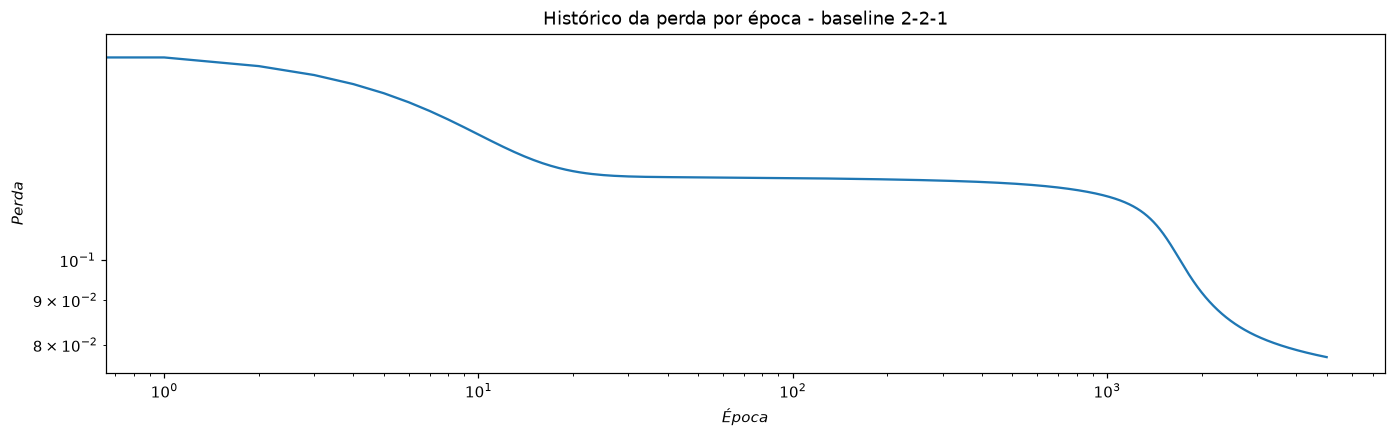

In [14]:
# Gráfico histórico da perda por época
fig, axes = plt.subplots(1, 1, figsize=(15, 4))
axes.set_title("Histórico da perda por época - baseline 2-2-1")
axes.set_xlabel("$Época$")
axes.set_ylabel("$Perda$")
# Escala logarítmica no eixo x e y
axes.set_xscale("log")
axes.set_yscale("log")
axes.plot(hist_base, c="tab:blue")
plt.show()

## 5.2 Fronteira de decisão do baseline

Com apenas dois neurônios ocultos a rede dispõe de duas retas no plano $(x_0, x_1)$: a saída combina dois semiplanos e **não consegue fechar uma região** em torno do círculo interno. A
figura abaixo mostra o que isso significa na prática.


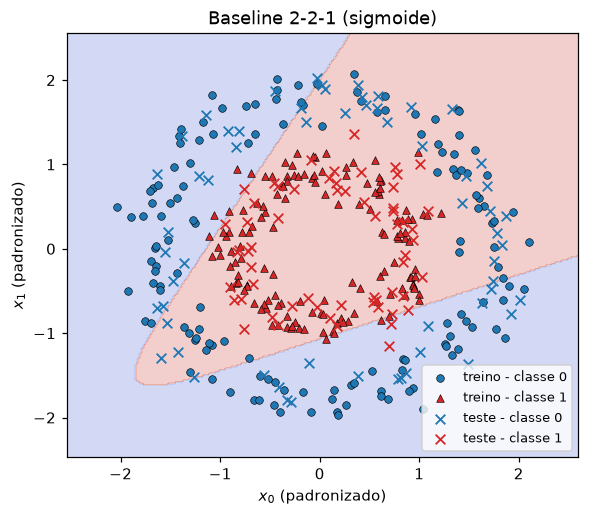

In [15]:
# Fronteira de decisão do baseline treinado (pesos_base da célula anterior).
#
pred_base = lambda M: np.array([prediz_baseline(x, *pesos_base) for x in M])
plota_fronteira(X_tr, Y_tr, pred_base, titulo="Baseline 2-2-1 (sigmoide)", X_teste=X_te, Y_teste=Y_te)
plt.show()


---
# 6. Rede proposta

## 6.1 Arquitetura escolhida

Uma única camada oculta, com o dobro da largura do baseline, e tanh no lugar da sigmoide nas
unidades ocultas:

$$\underbrace{2}_{\text{entrada}} \;\rightarrow\;
\underbrace{4}_{\tanh} \;\rightarrow\;
\underbrace{1}_{\text{sigmoide}}$$

| | Baseline | Proposta |
|---|---|---|
| Camadas ocultas | 1 | 1 |
| Neurônios ocultos | 2 | 4 |
| Ativação oculta | sigmoide | tanh |
| Ativação de saída | sigmoide | sigmoide |
| Parâmetros | $2{\cdot}2 + 2 + 2 + 1 = 9$ | $4{\cdot}2 + 4 + 4 + 1 = 17$ |

**Por que largura 4 e não mais.** Cada neurônio oculto define uma reta no plano $(x_0, x_1)$; a
camada de saída combina os semiplanos. Para cercar o anel interno do `make_circles` são necessárias
ao menos três retas (um triângulo), e quatro formam um quadrilátero com folga para o ruído. Ir além
aumentaria o backward manual e o grafo sem ganho conceitual — a seção de experimento mostra, via PyTorch, o
que acontece com larguras 8, 16 e 32.

**Por que uma camada só.** Mantém o backward manual no mesmo formato do `exemplo4.py`, o que torna
a comparação seção 5 × seção 6 direta: as únicas diferenças são a largura e a ativação. A
profundidade é estudada na seção de experimentos.

**Por que tanh.** Derivada máxima 1 (contra 0,25 da sigmoide) e saída centrada em
zero, de modo que as entradas do neurônio de saída não são todas positivas. Na saída a sigmoide é
mantida para que $y^{(2)} \in (0,1)$ funcione como probabilidade da classe 1.


> ⚠️ **Nota de projeto.** Como o forward e o backward são escritos de forma desenrolada,
> **cada** configuração de camadas/neurônios exige um par de funções novo. Escrever mais de duas ou
> três arquiteturas à mão é inviável dentro do prazo. Estratégia adotada: implementar à mão
> apenas o baseline (seção 5) e esta arquitetura proposta, e usar o PyTorch (seção 7) para varrer as
> demais variações de neurônios/camadas/ativação na seção 8. Essa divisão de papéis é uma decisão
> de projeto declarada, não uma omissão.

## 6.2 Inicialização dos pesos

O `exemplo4.py` usa `np.random.rand`, que sorteia em $U[0,1]$: todos os pesos positivos, com
média $0{,}5$. Dois problemas: (i) com entradas normalizadas, $v^{(1)}_i$ tem a mesma
distribuição para os quatro neurônios, que começam quase idênticos e demoram a se diferenciar;
(ii) a soma de termos positivos empurra $v$ para fora da região linear da tanh, onde a derivada
$1 - y^2$ tende a zero e o gradiente some.

Adota-se a inicialização de **Xavier/Glorot** (adequada a tanh e sigmoide):

$$w^{(\ell)}_{ij} \sim \mathcal{N}\!\left(0,\; \sigma^2 = \frac{1}{n_{\text{ent}}}\right),
\qquad b^{(\ell)}_i = 0$$

com $n_{\text{ent}} = 2$ na camada oculta e $n_{\text{ent}} = 4$ na saída. A variância
$1/n_{\text{ent}}$ mantém $\operatorname{Var}(v) \approx \operatorname{Var}(x)$ camada a camada,
o que preserva os potenciais na faixa em que a tanh ainda tem derivada apreciável. O sorteio usa
`np.random.default_rng(seed)` para ser reprodutível.


In [16]:
def inicializa_rede(seed=None, n_ocultos=N_OCULTOS) -> dict:
    """
    Inicializa a rede 2 -> n_ocultos -> 1 usando:

        w ~ N(0, 1 / n_ent)

    Portanto:
        sigma = sqrt(1 / n_ent)
    """

    rng = np.random.default_rng(seed)

    # Camada de entrada -> oculta
    # n_ent = 2
    W1 = rng.normal(
        loc=0.0,
        scale=np.sqrt(1 / 2),
        size=(n_ocultos, 2)
    )

    # Camada oculta -> saída
    # n_ent = n_ocultos
    W2 = rng.normal(
        loc=0.0,
        scale=np.sqrt(1 / n_ocultos),
        size=(n_ocultos,)
    )

    # Vieses
    b1 = np.zeros(n_ocultos)
    b2 = np.zeros(1)

    return {
        "W1": W1,
        "b1": b1,
        "W2": W2,
        "b2": b2
    }

## 6.3 Grafo da computação da rede proposta

Grafo computacional da rede 2→4→1 com o backward anotado: rótulos pretos são as variáveis de `forward`, rótulos vermelhos os gradientes de `backward` (prefixo `grad_`).


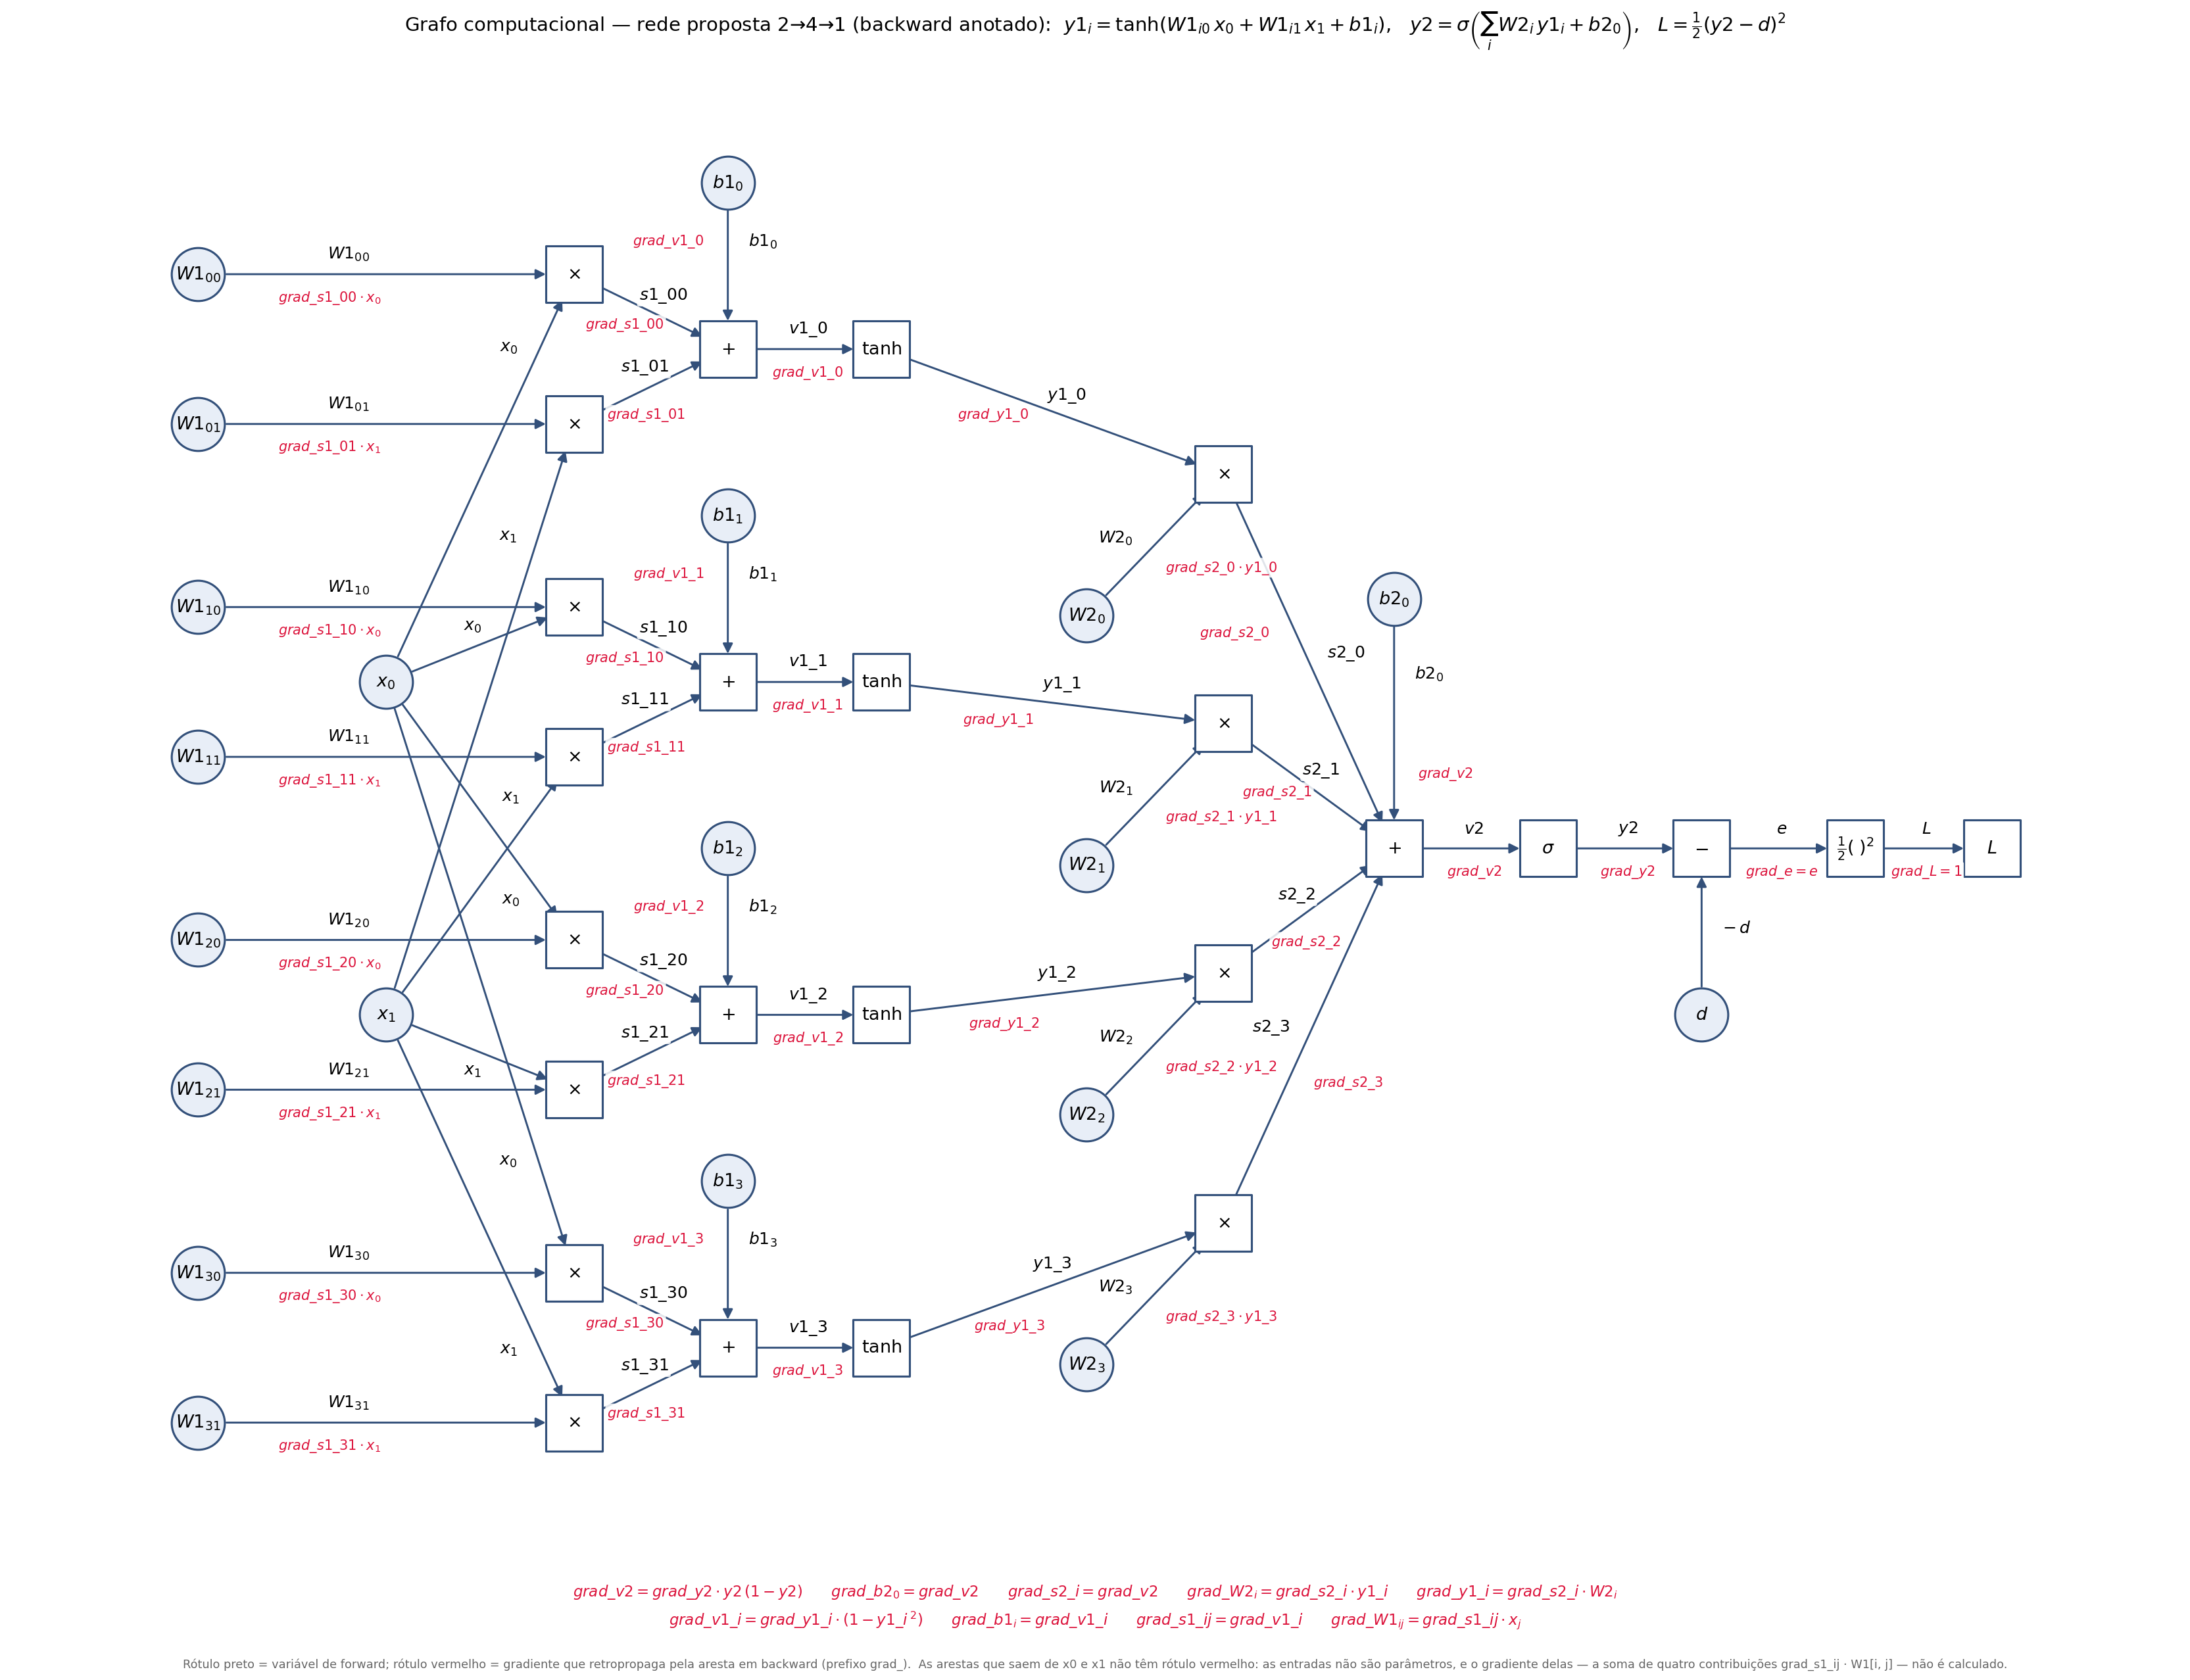

In [17]:
from IPython.display import Image
Image("figuras/grafos/grafo_proposta_2-4-1_backward.png")

## 6.4 Propagação direta

In [18]:
def forward(x, params) -> tuple:
    """Propagação direta da rede 2 -> 4 -> 1.

    Parâmetros
    ----------
    x      : ndarray (2,)  uma amostra
    params : dict          parâmetros retornados por inicializa_rede()

    Retorna
    -------
    y2    : float  saída da rede em (0, 1)
    cache : dict   valores intermediários usados no backward:
                   v1 (4,), y1 (4,), v2, y2
    """

    # Inicializar os parâmetros da rede
    W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]

    # Neurônio oculto 0
    s1_00 = W1[0, 0] * x[0]
    s1_01 = W1[0, 1] * x[1]
    v1_0 = s1_00 + s1_01 + b1[0]
    y1_0 = tanh(v1_0)

    # Neurônio oculto 1
    s1_10 = W1[1, 0] * x[0]
    s1_11 = W1[1, 1] * x[1]
    v1_1 = s1_10 + s1_11 + b1[1]
    y1_1 = tanh(v1_1)

    # Neurônio oculto 2
    s1_20 = W1[2, 0] * x[0]
    s1_21 = W1[2, 1] * x[1]
    v1_2 = s1_20 + s1_21 + b1[2]
    y1_2 = tanh(v1_2)

    # Neurônio oculto 3
    s1_30 = W1[3, 0] * x[0]
    s1_31 = W1[3, 1] * x[1]
    v1_3 = s1_30 + s1_31 + b1[3]
    y1_3 = tanh(v1_3)

    # Propagação para a camada de saída
    s2_0 = W2[0] * y1_0
    s2_1 = W2[1] * y1_1
    s2_2 = W2[2] * y1_2
    s2_3 = W2[3] * y1_3
    v2 = s2_0 + s2_1 + s2_2 + s2_3 + b2[0]
    y2 = sigmoid(v2)

    # Armazenar valores intermediários no cache
    cache = {
        "v1": np.array([v1_0, v1_1, v1_2, v1_3]),
        "y1": np.array([y1_0, y1_1, y1_2, y1_3]),
        "v2": v2,
        "y2": y2
    }

    return y2, cache

## 6.5 Retropropagação

In [19]:
def backward(x, d, params) -> tuple:
    """Retropropagação da rede 2 -> 4 -> 1

    Retorna
    -------
    grads : dict  mesmas chaves e formas de params, com os gradientes
    L     : float valor da perda para esta amostra
    """
    
    # 1) forward guardando o cache
    y2 , cache = forward(x, params)

    # Recuperar parâmetros necessários
    W2 = params["W2"]

    # Recuperar ativações intermediárias do cache
    y1 = cache["y1"]

    y1_0 = y1[0]
    y1_1 = y1[1]
    y1_2 = y1[2]
    y1_3 = y1[3]

    # 2) Erro e perda

    e = y2 - d   
    L = 0.5 * e**2

    # Criar estruturas para armazenar os gradientes
    grad_W1 = np.zeros(params["W1"].shape)
    grad_b1 = np.zeros(params["b1"].shape)

    grad_W2 = np.zeros(params["W2"].shape)
    grad_b2 = np.zeros(params["b2"].shape)

    # 3) Backward, na saída
    grad_L  = 1
    grad_e  = grad_L * e
    grad_y2 = grad_e

    # derivada da sigmoide da última camada.
    grad_v2 = grad_y2 * y2 * (1 - y2)
    # gradiente do bias de saída         
    grad_b2[0] = grad_v2
        
    # Neurônio oculto 0
    grad_s2_0   = grad_v2
    grad_W2[0]  = grad_s2_0 * y1_0
    grad_y1_0   = grad_s2_0 * W2[0]
    # derivada da tanh
    grad_v1_0   = grad_y1_0 * (1 - y1_0**2)
    grad_b1[0]  = grad_v1_0
    grad_s1_00  = grad_v1_0 ;  grad_s1_01 = grad_v1_0
    grad_W1[0, 0] = grad_s1_00 * x[0]
    grad_W1[0, 1] = grad_s1_01 * x[1]

    # Neurônio oculto 1
    grad_s2_1   = grad_v2
    grad_W2[1]  = grad_s2_1 * y1_1
    grad_y1_1   = grad_s2_1 * W2[1]
    # derivada da tanh
    grad_v1_1   = grad_y1_1 * (1 - y1_1**2)
    grad_b1[1]  = grad_v1_1
    grad_s1_10  = grad_v1_1 ;  grad_s1_11 = grad_v1_1   
    grad_W1[1, 0] = grad_s1_10 * x[0]
    grad_W1[1, 1] = grad_s1_11 * x[1]

    # Neurônio oculto 2
    grad_s2_2   = grad_v2
    grad_W2[2]  = grad_s2_2 * y1_2
    grad_y1_2   = grad_s2_2 * W2[2]
    # derivada da tanh
    grad_v1_2   = grad_y1_2 * (1 - y1_2**2)
    grad_b1[2]  = grad_v1_2
    grad_s1_20  = grad_v1_2 ;  grad_s1_21 = grad_v1_2   
    grad_W1[2, 0] = grad_s1_20 * x[0]
    grad_W1[2, 1] = grad_s1_21 * x[1]

    # Neurônio oculto 3
    grad_s2_3   = grad_v2
    grad_W2[3]  = grad_s2_3 * y1_3
    grad_y1_3   = grad_s2_3 * W2[3]
    # derivada da tanh
    grad_v1_3   = grad_y1_3 * (1 - y1_3**2)
    grad_b1[3]  = grad_v1_3
    grad_s1_30  = grad_v1_3 ;  grad_s1_31 = grad_v1_3   
    grad_W1[3, 0] = grad_s1_30 * x[0]
    grad_W1[3, 1] = grad_s1_31 * x[1]


    # 4) Organizando os gradientes 
    grads = {
        "W1": grad_W1,
        "b1": grad_b1,
        "W2": grad_W2,
        "b2": grad_b2
    }
    
    return grads, L


def perda(y2, d):
    """Função de perda de uma amostra: 0.5 * (y2 - d)**2"""
    return 0.5 * (y2 - d)**2


def prediz(x, params, limiar=0.5):
    """Classe predita para uma amostra: 1 se forward(x) >= limiar, senão 0."""
    if limiar < 0 or limiar > 1:
        raise ValueError(f"limiar deve estar em [0, 1], mas foi {limiar}")
    y2, _ = forward(x, params)
    return int(y2 >= limiar)


def acuracia(X, Y, params):
    """Fração de acertos sobre um conjunto."""
    acertos = 0
    for x, d in zip(X, Y):
        y_pred = prediz(x, params)
        if y_pred == d:
            acertos += 1
    return acertos / len(X)


## 6.6 Treinamento

In [20]:
def treina(X_tr, Y_tr, X_te=None, Y_te=None, taxa=TAXA, epocas=EPOCAS, seed=SEED, registra_cada=50) -> tuple:
    """Treina a rede proposta por gradiente descendente em batch.

    Retorna
    -------
    params    : dict  parâmetros treinados
    historico : dict  {"epoca": [...], "perda_tr": [...], "acc_tr": [...], "acc_te": [...]}

    """

    # 1. Inicializa o histórico de perda e acurácia
    historico = {
        "epoca": [],
        "perda_tr": [],
        "acc_tr": [],
        "acc_te": []
    }

    # 2. Inicializa a rede
    params = inicializa_rede(seed=seed, n_ocultos=N_OCULTOS)
    N = len(X_tr)

    # 3. Para cada época, calcular o gradiente médio e atualizar os parâmetros
    for epoca in range(epocas):
        # Zerar os acumuladores de gradiente e perda
        grads_acumulados = {chave: np.zeros_like(valor) for chave, valor in params.items()}
        perda_total = 0.0

        # Percorrer todas as amostras de treino
        for x, d in zip(X_tr, Y_tr):
            grads, L = backward(x, d, params)
            # Acumular gradientes
            for chave in grads:
                grads_acumulados[chave] += grads[chave]
            # Acumular perda
            perda_total += L

        # Calcular a média dos gradientes e da perda
        for chave in grads_acumulados:
            grads_acumulados[chave] /= N
        perda_media = perda_total / N

        # Registrar histórico a cada `registra_cada` épocas
        if (epoca % registra_cada == 0) or (epoca == epocas - 1):
            acc_tr = acuracia(X_tr, Y_tr, params)
            acc_te = acuracia(X_te, Y_te, params) if X_te is not None and Y_te is not None else None
            historico["epoca"].append(epoca)
            historico["perda_tr"].append(perda_media)
            historico["acc_tr"].append(acc_tr)
            historico["acc_te"].append(acc_te)

        # Atualizar os parâmetros da rede
        for chave in params:
            params[chave] -= taxa * grads_acumulados[chave]

    return params, historico

In [21]:
# Treinar a rede proposta e reportar os resultados.

params, hist = treina(X_tr, Y_tr, X_te, Y_te)
print(f"proposta | treino: {acuracia(X_tr, Y_tr, params):.3f}" f" | teste: {acuracia(X_te, Y_te, params):.3f}")

proposta | treino: 0.993 | teste: 0.992


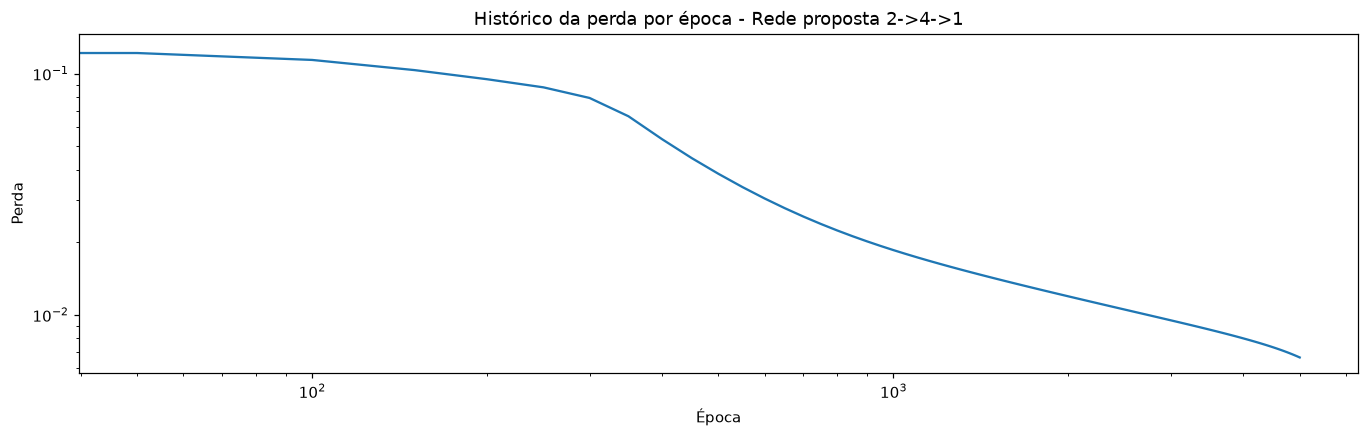

In [22]:
# Converter histórico para arrays NumPy
hist = {chave: np.array(valor) for chave, valor in hist.items()}

# Gráfico histórico da perda por época
fig, axes = plt.subplots(1, 1, figsize=(15, 4))

axes.set_title("Histórico da perda por época - Rede proposta 2->4->1")
axes.set_xlabel("Época")
axes.set_ylabel("Perda")

# Escala logarítmica no eixo x e y
axes.set_xscale("log")
axes.set_yscale("log")

# Plotar época x perda
axes.plot(
    hist["epoca"],
    hist["perda_tr"],
    c="tab:blue"
)

plt.show()

## 6.7 Fronteira de decisão da rede proposta

Quatro neurônios ocultos, quatro retas: a camada de saída pode combinar os semiplanos em um quadrilátero que **cerca** o círculo interno.


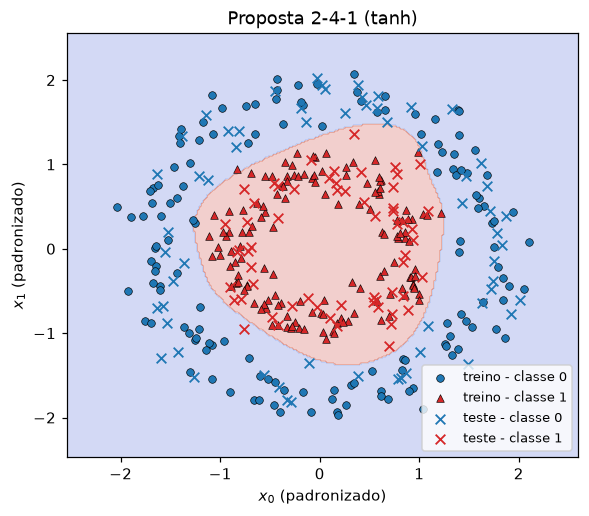

In [23]:
# Fronteira de decisão da rede proposta treinada (params da célula anterior).
pred_prop = lambda M: np.array([prediz(x, params) for x in M])
plota_fronteira(X_tr, Y_tr, pred_prop, 
                titulo="Proposta 2-4-1 (tanh)", 
                X_teste=X_te, 
                Y_teste=Y_te,
                fontsize="small")
plt.show()


---
# 7. Comparação com PyTorch

**Modificação em relação ao baseline:** o `exemplo4.py` compara com Keras. Aqui a comparação é feita
com PyTorch, que traz uma vantagem metodológica relevante para uma disciplina de matemática: o
`autograd` permite conferir os gradientes calculados à mão contra os da diferenciação automática.

In [24]:
try:
    import torch
    import torch.nn as nn
    print("torch:", torch.__version__)
except ImportError:
    print("PyTorch não instalado — instale as dependências com: pip install -r requirements.txt")

torch: 2.14.0+cpu


## 7.1 Rede equivalente em PyTorch

In [25]:
# Construir em PyTorch a MESMA arquitetura da seção 6 (2 -> 4 -> 1).

modelo = nn.Sequential(
       nn.Linear(2, N_OCULTOS), 
       nn.Tanh(),

       nn.Linear(N_OCULTOS, 1), 
       nn.Sigmoid(),
   )

## 7.2 Conferência dos gradientes contra o `autograd`

Copiar os pesos da implementação manual para o modelo PyTorch, calcular a perda na **mesma** amostra
e comparar `param.grad` com o gradiente produzido pela função `backward` da seção 6.5. Se ambos
coincidirem até a precisão de máquina, a derivação está confirmada por duas vias independentes.

In [26]:
# Conferir os gradientes em uma amostra (i = 0): allclose e diferença máxima por parâmetro.
params_iniciais = inicializa_rede(seed=SEED, n_ocultos=N_OCULTOS)

# Usar dupla precisão para permitir comparação com atol=1e-8
modelo = modelo.double()

# Escolher uma amostra
i = 0

x = X_tr[i]
d = Y_tr[i]

# ---------------------------------------------------------
# 1. Gradientes analíticos da nossa implementação NumPy
# ---------------------------------------------------------

grads_numpy, _ = backward(
    x,
    d,
    params_iniciais
)


# ---------------------------------------------------------
# 2. Copiar parâmetros NumPy -> PyTorch
# ---------------------------------------------------------

with torch.no_grad():

    # Primeira camada: NumPy (N_OCULTOS, 2)
    # PyTorch: (N_OCULTOS, 2)
    modelo[0].weight.copy_(
        torch.tensor(
            params_iniciais["W1"],
            dtype=torch.float64
        )
    )

    modelo[0].bias.copy_(
        torch.tensor(
            params_iniciais["b1"],
            dtype=torch.float64
        )
    )

    # Segunda camada: NumPy (N_OCULTOS,)
    # PyTorch: (1, N_OCULTOS)
    modelo[2].weight.copy_(
        torch.tensor(
            params_iniciais["W2"].reshape(1, -1),
            dtype=torch.float64
        )
    )

    modelo[2].bias.copy_(
        torch.tensor(
            params_iniciais["b2"],
            dtype=torch.float64
        )
    )


# ---------------------------------------------------------
# 3. Converter x e d para tensores
# ---------------------------------------------------------

x_tensor = torch.tensor(
    x,
    dtype=torch.float64
)

d_tensor = torch.tensor(
    d,
    dtype=torch.float64
)


# ---------------------------------------------------------
# 4. Zerar gradientes anteriores
# ---------------------------------------------------------

modelo.zero_grad()


# ---------------------------------------------------------
# 5. Forward + cálculo da perda
# ---------------------------------------------------------

y = modelo(x_tensor)

L = 0.5 * (y - d_tensor) ** 2

# Garantir que L seja escalar
L = L.sum()


# ---------------------------------------------------------
# 6. Backpropagation automático
# ---------------------------------------------------------

L.backward()


# ---------------------------------------------------------
# 7. Extrair gradientes do PyTorch
# ---------------------------------------------------------

grads_torch = {
    "W1": modelo[0].weight.grad.detach().numpy(),
    "b1": modelo[0].bias.grad.detach().numpy(),

    "W2": modelo[2].weight.grad.detach().numpy().reshape(-1),
    "b2": modelo[2].bias.grad.detach().numpy()
}


# ---------------------------------------------------------
# 8. Comparar NumPy × PyTorch
# ---------------------------------------------------------

for chave in grads_numpy:

    confere = np.allclose(
        grads_numpy[chave],
        grads_torch[chave],
        atol=1e-8
    )

    maior_diferenca = np.max(
        np.abs(
            grads_numpy[chave]
            - grads_torch[chave]
        )
    )

    print(
        f"{chave}: "
        f"allclose = {confere} | "
        f"máx. diferença = {maior_diferenca:.2e}"
    )

W1: allclose = True | máx. diferença = 0.00e+00
b1: allclose = True | máx. diferença = 0.00e+00
W2: allclose = True | máx. diferença = 0.00e+00
b2: allclose = True | máx. diferença = 0.00e+00


## 7.3 Treinamento e comparação de desempenho

In [27]:
# Treinar o modelo PyTorch nas MESMAS condições (mesma semente, mesma taxa, mesmas épocas,
# mesmo split) e comparar acurácia e curva de perda com a implementação manual.
# Diferenças residuais devem ser explicadas (inicialização, ordem das operações em ponto flutuante).

# ============================================================
# Treinamento PyTorch nas mesmas condições da implementação manual
# ============================================================

# Trabalhar em float64 para reduzir diferenças numéricas
modelo = modelo.double()

# ------------------------------------------------------------
# 1. Copiar os mesmos parâmetros iniciais da implementação manual
# ------------------------------------------------------------

with torch.no_grad():

    modelo[0].weight.copy_(
        torch.tensor(
            params_iniciais["W1"],
            dtype=torch.float64
        )
    )

    modelo[0].bias.copy_(
        torch.tensor(
            params_iniciais["b1"],
            dtype=torch.float64
        )
    )

    modelo[2].weight.copy_(
        torch.tensor(
            params_iniciais["W2"].reshape(1, -1),
            dtype=torch.float64
        )
    )

    modelo[2].bias.copy_(
        torch.tensor(
            params_iniciais["b2"],
            dtype=torch.float64
        )
    )


# ------------------------------------------------------------
# 2. Converter os conjuntos de treino e teste para PyTorch
# ------------------------------------------------------------

X_tr_torch = torch.tensor(
    X_tr,
    dtype=torch.float64
)

Y_tr_torch = torch.tensor(
    Y_tr,
    dtype=torch.float64
).reshape(-1, 1)

X_te_torch = torch.tensor(
    X_te,
    dtype=torch.float64
)

Y_te_torch = torch.tensor(
    Y_te,
    dtype=torch.float64
).reshape(-1, 1)


# ------------------------------------------------------------
# 3. Otimizador
# ------------------------------------------------------------

otimizador = torch.optim.SGD(
    modelo.parameters(),
    lr=TAXA
)


# ------------------------------------------------------------
# 4. Histórico
# ------------------------------------------------------------

hist_torch = {
    "epoca": [],
    "perda_tr": [],
    "acc_tr": [],
    "acc_te": []
}


# ------------------------------------------------------------
# 5. Treinamento
# ------------------------------------------------------------

for epoca in range(EPOCAS):

    # Zerar gradientes acumulados
    otimizador.zero_grad()

    # Forward
    y_pred = modelo(X_tr_torch)

    # Mesma perda da implementação manual:
    # 0.5 * média dos erros quadráticos
    perda_torch = 0.5 * torch.mean(
        (y_pred - Y_tr_torch) ** 2
    )

    # Backward
    perda_torch.backward()


    # --------------------------------------------------------
    # Registrar histórico
    # --------------------------------------------------------

    if (epoca % 50 == 0) or (epoca == EPOCAS - 1):

        with torch.no_grad():

            # Treino
            y_tr_pred = modelo(X_tr_torch)

            classe_tr = (
                y_tr_pred >= 0.5
            ).double()

            acc_tr = (
                classe_tr == Y_tr_torch
            ).double().mean().item()

            # Teste
            y_te_pred = modelo(X_te_torch)

            classe_te = (
                y_te_pred >= 0.5
            ).double()

            acc_te = (
                classe_te == Y_te_torch
            ).double().mean().item()

            # Perda de treino
            perda_registro = (
                0.5
                * torch.mean(
                    (y_tr_pred - Y_tr_torch) ** 2
                )
            ).item()

        hist_torch["epoca"].append(epoca)
        hist_torch["perda_tr"].append(perda_registro)
        hist_torch["acc_tr"].append(acc_tr)
        hist_torch["acc_te"].append(acc_te)

    # Atualização dos pesos
    otimizador.step()

In [28]:
# Reportar os resultados.
print(f"proposta | treino: {hist_torch['acc_tr'][-1]:.3f}" f" | teste: {hist_torch['acc_te'][-1]:.3f}")

proposta | treino: 0.993 | teste: 0.992


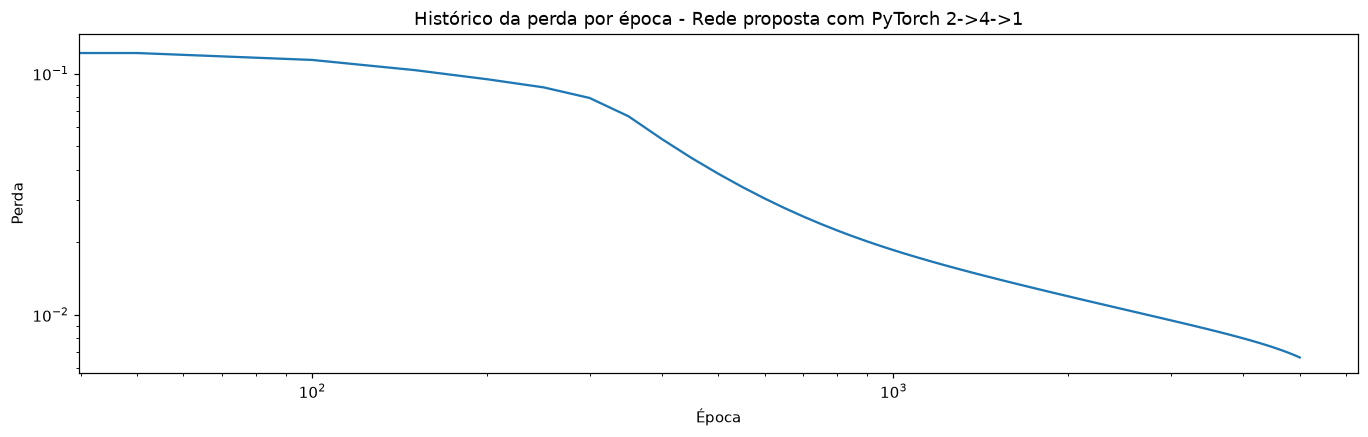

In [29]:
# Gráfico histórico da perda por época
fig, axes = plt.subplots(1, 1, figsize=(15, 4))

axes.set_title("Histórico da perda por época - Rede proposta com PyTorch 2->4->1")
axes.set_xlabel("Época")
axes.set_ylabel("Perda")

# Escala logarítmica no eixo x y
axes.set_xscale("log")
axes.set_yscale("log")

# Plotar época x perda
axes.plot(
    hist_torch["epoca"],
    hist_torch["perda_tr"],
    c="tab:blue"
)

plt.show()

## 7.4 Fronteira de decisão do modelo PyTorch

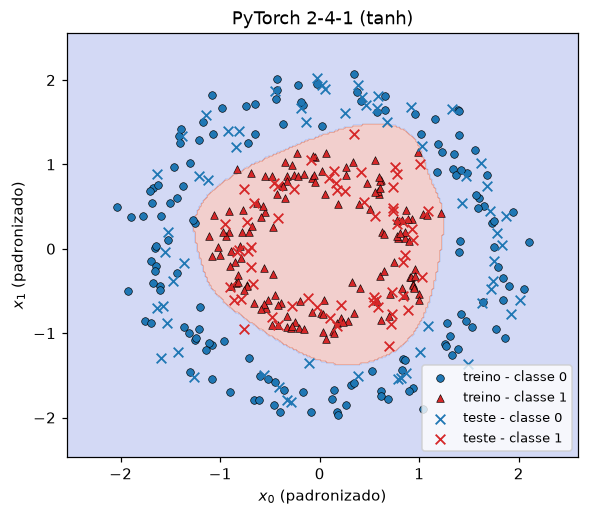

In [30]:
# Fronteira de decisão do modelo PyTorch treinado (modelo da célula anterior).

modelo.eval()
with torch.no_grad():
    pred_torch = lambda M: (modelo(torch.tensor(M, dtype=torch.float64))
                            .detach().numpy().ravel() >= 0.5).astype(int)
    plota_fronteira(X_tr, Y_tr, pred_torch, titulo="PyTorch 2-4-1 (tanh)",
                    X_teste=X_te, Y_teste=Y_te)
plt.show()

---
# 8. Experimentos

Cada subseção isola **uma** variável, mantendo as demais fixas — é isso que permite atribuir a
diferença de desempenho ao fator estudado. Rodei cada configuração com algumas sementes diferentes e
reportei a média e desvio-padrão: uma única execução não distingue efeito real de sorte na
inicialização.

Usa-se o PyTorch para varrer as arquiteturas — a implementação
desenrolada cobre apenas o baseline e a proposta.

In [31]:
ATIVACOES = {"tanh": nn.Tanh, "relu": nn.ReLU, "sigmoid": nn.Sigmoid}


def constroi_modelo(camadas, ativacao) -> nn.Sequential:
    """Monta um nn.Sequential a partir da lista de larguras, ex.: [2, 8, 8, 1].

    Todas as camadas ocultas usam `ativacao`; a saída é sempre sigmoide (ATIV_SAIDA) 
    — o que muda entre os experimentos é só a parte oculta.
    """
    blocos = []
    for i in range(len(camadas) - 1):
        blocos.append(nn.Linear(camadas[i], camadas[i + 1]))
        ultima = (i == len(camadas) - 2)
        blocos.append(nn.Sigmoid() if ultima else ATIVACOES[ativacao]())
    return nn.Sequential(*blocos).double()


def treina_torch(modelo, X_tr, Y_tr, X_te, Y_te, taxa=TAXA, epocas=EPOCAS, registra_cada=50) -> tuple:
    """Gradiente descendente em batch, mesmo laço da seção 7.3, agora como função.

    Retorna (acc_tr, acc_te, perda_final, historico); historico = {"epoca": [...], "perda_tr": [...]}.
    """
    Xtr = torch.tensor(X_tr, dtype=torch.float64)
    Ytr = torch.tensor(Y_tr, dtype=torch.float64).reshape(-1, 1)
    Xte = torch.tensor(X_te, dtype=torch.float64)
    Yte = torch.tensor(Y_te, dtype=torch.float64).reshape(-1, 1)

    otimizador = torch.optim.SGD(modelo.parameters(), lr=taxa)
    historico = {"epoca": [], "perda_tr": []}

    for epoca in range(epocas):
        otimizador.zero_grad()
        perda = 0.5 * torch.mean((modelo(Xtr) - Ytr) ** 2)
        perda.backward()
        if (epoca % registra_cada == 0) or (epoca == epocas - 1):
            historico["epoca"].append(epoca)
            historico["perda_tr"].append(perda.item())
        otimizador.step()

    with torch.no_grad():
        acc_tr = ((modelo(Xtr) >= 0.5).double() == Ytr).double().mean().item()
        acc_te = ((modelo(Xte) >= 0.5).double() == Yte).double().mean().item()
        perda_final = (0.5 * torch.mean((modelo(Xtr) - Ytr) ** 2)).item()

    return acc_tr, acc_te, perda_final, historico


def experimento(camadas, ativacao, taxa=TAXA, epocas=EPOCAS, sementes=(13, 14, 22, 30, 55, 70)) -> dict:
    """Treina uma configuração com várias sementes e devolve as métricas agregadas.

    Parâmetros
    ----------
    camadas  : list[int]  ex.: [2, 4, 1] (a proposta) ou [2, 8, 8, 1]
    ativacao : str        "tanh" | "relu" | "sigmoid"

    Retorna
    -------
    dict com acurácia média e desvio-padrão em treino e teste, e a perda final.
    A chave "curvas" guarda o histórico de perda de cada semente.
    """
    acc_tr, acc_te, perdas, curvas = [], [], [], []

    for semente in sementes:
        torch.manual_seed(semente)                  # controla a inicialização de nn.Linear
        modelo = constroi_modelo(camadas, ativacao)
        a_tr, a_te, perda, hist_s = treina_torch(modelo, X_tr, Y_tr, X_te, Y_te, taxa, epocas)
        acc_tr.append(a_tr); acc_te.append(a_te); perdas.append(perda); curvas.append(hist_s)

    n_params = sum(p.numel() for p in modelo.parameters())

    return {
        "camadas":       "-".join(map(str, camadas)),
        "ativacao":      ativacao,
        "taxa":          taxa,
        "n_params":      n_params,
        "acc_tr_media":  np.mean(acc_tr), "acc_tr_dp": np.std(acc_tr),
        "acc_te_media":  np.mean(acc_te), "acc_te_dp": np.std(acc_te),
        "perda_media":   np.mean(perdas),
        "curvas":        curvas,
    }


resultados = []   # lista de dicts, consolidada na tabela de consolidação

## 8.1 Efeito do número de neurônios por camada

In [32]:
# Fixar 1 camada oculta e tanh; variar a largura, ex.: [2, 4, 8, 16, 32].
# As larguras 2 e 4 reproduzem, em PyTorch, o baseline e a proposta — servem de sanidade.
larguras = [2, 4, 8, 16, 32]
for largura in larguras:
    camadas = [2, largura, 1]
    res = experimento(camadas, ativacao="tanh", sementes=(13, 14, 22, 30, 55, 70))
    resultados.append(res)
    print(f"{res['camadas']} | "
          f"acc_tr: {res['acc_tr_media']:.3f} ± {res['acc_tr_dp']:.3f} | "
          f"acc_te: {res['acc_te_media']:.3f} ± {res['acc_te_dp']:.3f} | "
          f"perda: {res['perda_media']:.3e} | "
          f"n_params: {res['n_params']}")
    

2-2-1 | acc_tr: 0.805 ± 0.003 | acc_te: 0.739 ± 0.006 | perda: 7.414e-02 | n_params: 9


2-4-1 | acc_tr: 0.994 ± 0.003 | acc_te: 0.979 ± 0.010 | perda: 6.821e-03 | n_params: 17


2-8-1 | acc_tr: 0.997 ± 0.001 | acc_te: 0.976 ± 0.007 | perda: 2.928e-03 | n_params: 33


2-16-1 | acc_tr: 0.998 ± 0.002 | acc_te: 0.976 ± 0.006 | perda: 2.283e-03 | n_params: 65


2-32-1 | acc_tr: 1.000 ± 0.000 | acc_te: 0.976 ± 0.003 | perda: 1.906e-03 | n_params: 129


## 8.2 Efeito do número de camadas

In [33]:
# Manter o total de parâmetros aproximadamente constante e variar a profundidade,
# ex.: [2,4,1] (17 par.) / [2,3,3,1] (25 par.) / [2,16,1] / [2,8,8,1] / [2,6,6,6,1].

profundidades = [
    [2, 4, 1],      # proposta (referência)
    [2, 3, 3, 1],   # 2 camadas
    [2, 16, 1],     # 1 camada larga
    [2, 8, 8, 1],   # 2 camadas
    [2, 6, 6, 6, 1] # 3 camadas
]
for camadas in profundidades:
    res = experimento(camadas, ativacao="tanh", sementes=(13, 14, 22, 30, 55, 70))
    resultados.append(res)
    print(f"{res['camadas']} | "
          f"acc_tr: {res['acc_tr_media']:.3f} ± {res['acc_tr_dp']:.3f} | "
          f"acc_te: {res['acc_te_media']:.3f} ± {res['acc_te_dp']:.3f} | "
          f"perda: {res['perda_media']:.3e} | "
          f"n_params: {res['n_params']}")

2-4-1 | acc_tr: 0.994 ± 0.003 | acc_te: 0.979 ± 0.010 | perda: 6.821e-03 | n_params: 17


2-3-3-1 | acc_tr: 0.999 ± 0.001 | acc_te: 0.986 ± 0.004 | perda: 8.191e-04 | n_params: 25


2-16-1 | acc_tr: 0.998 ± 0.002 | acc_te: 0.976 ± 0.006 | perda: 2.283e-03 | n_params: 65


2-8-8-1 | acc_tr: 1.000 ± 0.000 | acc_te: 0.988 ± 0.004 | perda: 3.670e-04 | n_params: 105


2-6-6-6-1 | acc_tr: 1.000 ± 0.000 | acc_te: 0.990 ± 0.003 | perda: 8.471e-05 | n_params: 109


## 8.3 Efeito da função de ativação

In [34]:
# Mesma arquitetura 2 -> 4 -> 1, variando a ativação oculta: sigmoide / tanh / ReLU.

ativacoes = ["sigmoid", "tanh", "relu"]
for ativacao in ativacoes:
    res = experimento([2, 4, 1], ativacao=ativacao, sementes=(13, 14, 22, 30, 55, 70))
    resultados.append(res)
    print(f"{res['camadas']} | "
          f"ativacao: {res['ativacao']} | "
          f"acc_tr: {res['acc_tr_media']:.3f} ± {res['acc_tr_dp']:.3f} | "
          f"acc_te: {res['acc_te_media']:.3f} ± {res['acc_te_dp']:.3f} | "
          f"perda: {res['perda_media']:.3e} | "
          f"n_params: {res['n_params']}")

2-4-1 | ativacao: sigmoid | acc_tr: 0.988 ± 0.005 | acc_te: 0.961 ± 0.023 | perda: 1.245e-02 | n_params: 17


2-4-1 | ativacao: tanh | acc_tr: 0.994 ± 0.003 | acc_te: 0.979 ± 0.010 | perda: 6.821e-03 | n_params: 17


2-4-1 | ativacao: relu | acc_tr: 0.964 ± 0.072 | acc_te: 0.935 ± 0.087 | perda: 1.465e-02 | n_params: 17


## 8.4 Efeito da taxa de aprendizado

In [35]:
# Varrer eta em escala logarítmica, ex.: [0.001, 0.01, 0.1, 0.5, 1.0, 10.0, 100.0].
# Mostrar os três regimes: convergência lenta demais, convergência adequada e divergência.

etas = [0.001, 0.01, 0.1, 0.5, 1.0, 10.0, 100.0]
for eta in etas:
    res = experimento([2, 4, 1], ativacao="tanh", taxa=eta, sementes=(13, 14, 22, 30, 55, 70))
    resultados.append(res)
    print(f"{res['camadas']} | "
          f"eta: {res['taxa']:.3f} | "
          f"acc_tr: {res['acc_tr_media']:.3f} ± {res['acc_tr_dp']:.3f} | "
          f"acc_te: {res['acc_te_media']:.3f} ± {res['acc_te_dp']:.3f} | "
          f"perda: {res['perda_media']:.3e} | "
          f"n_params: {res['n_params']}")

2-4-1 | eta: 0.001 | acc_tr: 0.496 ± 0.052 | acc_te: 0.483 ± 0.064 | perda: 1.265e-01 | n_params: 17


2-4-1 | eta: 0.010 | acc_tr: 0.644 ± 0.093 | acc_te: 0.618 ± 0.081 | perda: 1.196e-01 | n_params: 17


2-4-1 | eta: 0.100 | acc_tr: 0.983 ± 0.006 | acc_te: 0.964 ± 0.014 | perda: 3.174e-02 | n_params: 17


2-4-1 | eta: 0.500 | acc_tr: 0.986 ± 0.005 | acc_te: 0.965 ± 0.015 | perda: 1.061e-02 | n_params: 17


2-4-1 | eta: 1.000 | acc_tr: 0.994 ± 0.003 | acc_te: 0.979 ± 0.010 | perda: 6.821e-03 | n_params: 17


2-4-1 | eta: 10.000 | acc_tr: 0.990 ± 0.006 | acc_te: 0.969 ± 0.020 | perda: 4.550e-03 | n_params: 17


2-4-1 | eta: 100.000 | acc_tr: 0.803 ± 0.133 | acc_te: 0.779 ± 0.117 | perda: 9.661e-02 | n_params: 17


## 8.5 Tabela consolidada

In [36]:
import pandas as pd

df = pd.DataFrame(resultados).sort_values("acc_te_media", ascending=False)
display(df.round(4))
df.to_csv("resultados/resultados_experimentos.csv", index=False)

,camadas,ativacao,taxa,n_params,acc_tr_media,acc_tr_dp,acc_te_media,acc_te_dp,perda_media,curvas
9,2-6-6-6-1,tanh,1.000,109,1.0000,0.0000,0.9903,0.0031,0.0001,"[{'epoca': [0, 50, 100, 150, 200, 250, 300, 35..."
8,2-8-8-1,tanh,1.000,105,1.0000,0.0000,0.9875,0.0042,0.0004,"[{'epoca': [0, 50, 100, 150, 200, 250, 300, 35..."
6,2-3-3-1,tanh,1.000,25,0.9994,0.0013,0.9861,0.0039,0.0008,"[{'epoca': [0, 50, 100, 150, 200, 250, 300, 35..."
1,2-4-1,tanh,1.000,17,0.9940,0.0034,0.9792,0.0105,0.0068,"[{'epoca': [0, 50, 100, 150, 200, 250, 300, 35..."
11,2-4-1,tanh,1.000,17,0.9940,0.0034,0.9792,0.0105,0.0068,"[{'epoca': [0, 50, 100, 150, 200, 250, 300, 35..."
17,2-4-1,tanh,1.000,17,0.9940,0.0034,0.9792,0.0105,0.0068,"[{'epoca': [0, 50, 100, 150, 200, 250, 300, 35..."
5,2-4-1,tanh,1.000,17,0.9940,0.0034,0.9792,0.0105,0.0068,"[{'epoca': [0, 50, 100, 150, 200, 250, 300, 35..."
2,2-8-1,tanh,1.000,33,0.9970,0.0013,0.9764,0.0075,0.0029,"[{'epoca': [0, 50, 100, 150, 200, 250, 300, 35..."
7,2-16-1,tanh,1.000,65,0.9982,0.0018,0.9764,0.0057,0.0023,"[{'epoca': [0, 50, 100, 150, 200, 250, 300, 35..."
3,2-16-1,tanh,1.000,65,0.9982,0.0018,0.9764,0.0057,0.0023,"[{'epoca': [0, 50, 100, 150, 200, 250, 300, 35..."


---
# 9. Análise dos resultados

## 9.1 Curva de perda

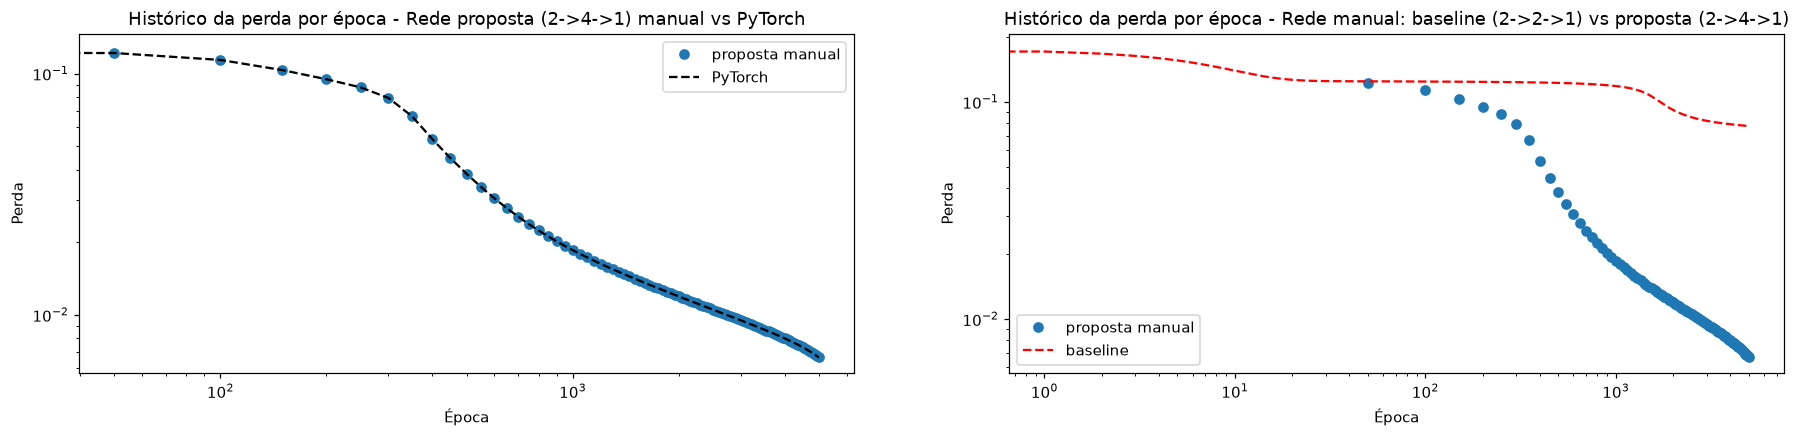

In [37]:
# Plotar a perda por época — manual x PyTorch, e/ou baseline x proposta.

# Gráfico histórico da perda por época
fig, axes = plt.subplots(1, 2, figsize=(20, 4))

#--------------------------------------------------------------------------------------------#
#           "Histórico da perda por época - Rede proposta (2->4->1) manual vs PyTorch"       #
#--------------------------------------------------------------------------------------------#
axes[0].set_title("Histórico da perda por época - Rede proposta (2->4->1) manual vs PyTorch")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Perda")


# Plotar época x perda
axes[0].plot(
    hist["epoca"],
    hist["perda_tr"],
    c="tab:blue",
    marker="o",
    linestyle="None"
)
axes[0].plot(
    hist_torch["epoca"],
    hist_torch["perda_tr"],
    c="black",
    linestyle="--",
)

#-----------------------------------------------------------------------------------------------#
#  "Histórico da perda por época - Rede baseline (2->2->1) vs proposta manual (2->4->1)"       #
#-----------------------------------------------------------------------------------------------#

axes[1].set_title("Histórico da perda por época - Rede manual: baseline (2->2->1) vs proposta (2->4->1)")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Perda")

# Plotar época x perda
axes[1].plot(
    hist["epoca"],
    hist["perda_tr"],
    c="tab:blue",
    marker="o",
    linestyle="None"
)
axes[1].plot(
    hist_base,
    c="red",
    linestyle="--"
)

#---------------------------------------------------------------#
#           Organização dos gráficos, escalas e legendas        #
#---------------------------------------------------------------#

# Escala logarítmica no eixo x
axes[0].set_xscale("log")
axes[1].set_xscale("log")
# Escala logarítmica no eixo y
axes[0].set_yscale("log")
axes[1].set_yscale("log")


# Legenda
axes[0].legend(["proposta manual", "PyTorch"])
axes[1].legend(["proposta manual","baseline"])

plt.show()



## 9.2 Fronteira de decisão — comparação

As fronteiras individuais estão nas seções 5.2 (baseline), 6.7 (proposta) e 7.4 (PyTorch). Aqui
elas aparecem **lado a lado, na mesma escala**, para que a diferença de capacidade entre as
arquiteturas seja lida de uma vez só.


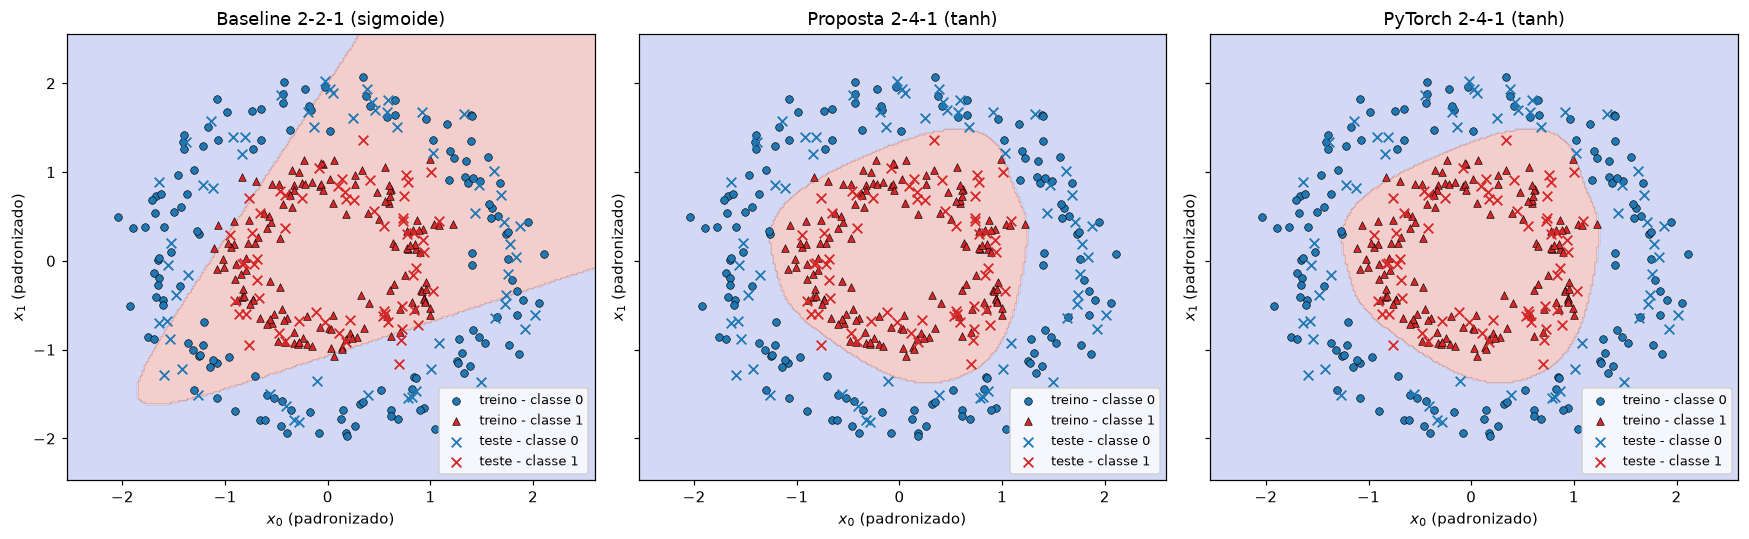

In [38]:
# As três fronteiras lado a lado, reaproveitando os adaptadores pred_base, pred_prop
# e pred_torch
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

for ax, (pred, titulo) in zip(axes, [(pred_base,  "Baseline 2-2-1 (sigmoide)"),
                                    (pred_prop,  "Proposta 2-4-1 (tanh)"),
                                    (pred_torch, "PyTorch 2-4-1 (tanh)")]):
    plota_fronteira(X_tr, Y_tr, pred, titulo=titulo, ax=ax, X_teste=X_te, Y_teste=Y_te)
plt.tight_layout()
plt.show()


## 9.3 Matriz de confusão e métricas

In [39]:
# Matriz de confusão, acurácia, precisão, revocação e F1 no conjunto de TESTE.
#
for nome, pred in [("baseline 2-2-1", pred_base),
                   ("proposta 2-4-1", pred_prop),
                   ("PyTorch 2-4-1",  pred_torch)]:
    y_pred = pred(X_te)
    print(f"=== {nome} ===")
    print("matriz de confusão (linhas: real 0/1, colunas: previsto 0/1):")
    print(confusion_matrix(Y_te, y_pred))
    print(classification_report(Y_te, y_pred, digits=3))

=== baseline 2-2-1 ===
matriz de confusão (linhas: real 0/1, colunas: previsto 0/1):
[[32 28]
 [ 3 57]]
              precision    recall  f1-score   support

           0      0.914     0.533     0.674        60
           1      0.671     0.950     0.786        60

    accuracy                          0.742       120
   macro avg      0.792     0.742     0.730       120
weighted avg      0.792     0.742     0.730       120

=== proposta 2-4-1 ===
matriz de confusão (linhas: real 0/1, colunas: previsto 0/1):
[[60  0]
 [ 1 59]]
              precision    recall  f1-score   support

           0      0.984     1.000     0.992        60
           1      1.000     0.983     0.992        60

    accuracy                          0.992       120
   macro avg      0.992     0.992     0.992       120
weighted avg      0.992     0.992     0.992       120

=== PyTorch 2-4-1 ===
matriz de confusão (linhas: real 0/1, colunas: previsto 0/1):
[[60  0]
 [ 1 59]]
              precision    recall  

---
# 10. Conclusão

## 10.1 O que foi feito

A partir do `exemplo4.py`, foram alteradas a base de dados (`make_moons` → `make_circles`), a
largura da camada oculta (2 → 4 neurônios) e a função de ativação oculta (sigmoide → tanh),
mantendo uma única camada oculta, a sigmoide na saída e a perda ½e². A propagação direta e a
retropropagação da rede 2 → 4 → 1 foram escritas à mão, operação por operação, e os gradientes
resultantes coincidiram com os do `autograd` do PyTorch com diferença máxima igual a zero
(seção 7.2). Essa conferência é o resultado que sustenta todo o restante: o backward manual
está correto.

## 10.2 Resultados principais

Acurácia no conjunto de teste (120 amostras, semente 13):

| Modelo | Treino | Teste | Parâmetros |
|---|---|---|---|
| Baseline 2 → 2 → 1 (sigmoide) | 0,796 | 0,742 | 9 |
| Proposta 2 → 4 → 1 (tanh), manual | 0,993 | 0,992 | 17 |
| Proposta 2 → 4 → 1 (tanh), PyTorch | 0,993 | 0,992 | 17 |

A matriz de confusão do baseline (seção 9.3) mostra onde ele falha: acerta 57 dos 60 pontos
da classe interna, mas classifica 28 dos 60 pontos da classe externa como internos. Com duas
retas a rede só consegue definir uma faixa do plano, e coloca o anel interno dentro dela
junto com parte do anel externo. Com quatro retas a rede proposta fecha um quadrilátero em
torno do anel interno e erra um único ponto de teste. A fronteira desenhada na seção 9.2
torna isso visível.

A implementação manual e a do PyTorch, partindo dos mesmos pesos iniciais, produziram a mesma
acurácia e a mesma matriz de confusão, e as curvas de perda da seção 9.1 se sobrepõem.

## 10.3 O que os experimentos mostraram

Os experimentos da seção 8 foram feitos em PyTorch, com seis sementes por configuração, e
reportam média ± desvio-padrão da acurácia de teste.

**Largura (8.1).** O salto está entre 2 e 4 neurônios: 0,739 → 0,979. De 4 para 32 a acurácia
de teste fica estável em torno de 0,976, enquanto a de treino sobe até 1,000. Mais largura só
ajusta melhor o ruído do conjunto de treino; quatro neurônios são de fato o mínimo suficiente
para este problema.

**Profundidade (8.2).** Com número de parâmetros comparável, redes mais profundas foram
mais eficientes: 2 → 3 → 3 → 1, com 25 parâmetros, alcançou 0,986, acima dos 0,976 de
2 → 16 → 1 com 65 parâmetros. A configuração 2 → 6 → 6 → 6 → 1 chegou a 0,990. O ganho é
pequeno em relação à proposta e vem ao custo de um backward manual bem maior, o que justifica
a escolha de uma camada só neste trabalho.

**Ativação (8.3).** Na mesma arquitetura 2 → 4 → 1, a tanh (0,979 ± 0,010) superou a sigmoide
(0,961 ± 0,023) e a ReLU (0,935 ± 0,087). O desvio-padrão da ReLU é o dado mais informativo:
com apenas quatro unidades, uma ou duas que morrem (saída zero para todas as entradas) já
comprometem a rede, e o resultado passa a depender da sorte na inicialização.

**Taxa de aprendizado (8.4).** Com o gradiente calculado como média sobre as amostras,
taxas de 0,001 e 0,01 não convergem em 5.000 épocas (acurácia próxima de chance); entre 0,1
e 10 a rede converge, com o melhor resultado em 1,0; em 100 a acurácia cai para 0,779 com
desvio-padrão alto, sinal de oscilação. A escolha de η = 1,0 nas seções 5 a 7 está no meio da
faixa útil.

## 10.4 Limitações

- O resultado de 0,992 da rede proposta corresponde a uma única semente; a média sobre seis
  sementes na mesma configuração (seção 8.1) é 0,979 ± 0,010. A execução principal ficou na
  ponta superior da distribuição.
- O problema é pequeno (400 pontos, duas dimensões) e o gradiente é calculado em lote completo.
  Conclusões sobre largura e profundidade não se transferem diretamente a problemas maiores.
- O backward desenrolado só cobre duas arquiteturas. Variações além delas dependem do
  PyTorch, o que foi uma decisão declarada, não uma verificação manual.

## 10.5 Fechamento

O objetivo da atividade era projetar e implementar uma rede a partir do `exemplo4.py`,
justificando as modificações. As três alterações se mostraram necessárias e suficientes para o
problema escolhido: a base de círculos concêntricos exige uma região fechada, quatro neurônios
são o mínimo que a produz, e a tanh entrega a convergência mais estável entre as ativações
testadas. A retropropagação manual, conferida contra o `autograd`, foi o ponto em que a
matemática da disciplina se materializou em código.